# Artículo 1 — auditoría experimental y cuaderno editorial

La primera salida es la cobertura **auditada**, no el estado de un proceso. Este notebook es el único punto de entrada: copia entradas explícitas, verifica fuentes y pares, calcula estadísticas desde ejecuciones individuales y exporta PNG/PDF y CSV/LaTeX. No entrena ni modifica resultados originales. Los informes del 9 de septiembre se conservan como históricos y no suministran observaciones.

**Reproducción:** kernel Python con las dependencias de `requirements.txt`, desde la raíz o `notebooks/`; ejecutar todas las celdas. Las rutas se fijan en la siguiente celda. La auditoría puede tardar varios minutos leyendo los 540 checkpoints en CPU. `OUTPUTS/article1_paper/` es exclusivamente salida de análisis; las copias y el manifiesto contienen rutas, hashes, fechas, commits, exclusiones y alcance de las verificaciones.

In [1]:
from pathlib import Path
import os, sys, json
os.environ.setdefault("MPLCONFIGDIR", "/tmp/article1-mpl")
os.environ.setdefault("OMP_NUM_THREADS", "1")
ROOT = Path.cwd().resolve()
if not (ROOT / "article1").is_dir():
    ROOT = ROOT.parent
assert (ROOT / "article1").is_dir(), "Ejecutar desde raíz o notebooks/"
sys.path.insert(0, str(ROOT))
SOURCE = ROOT / "OUTPUTS/article1_v3"
OUT = ROOT / "OUTPUTS/article1_paper"
# Selección explícita: no mezclar automáticamente el último fichero de cada snapshot.
# FedDF fue localizado mediante launch_*.json y búsqueda de directorios accesibles.
FEDDF = SOURCE / "results_proxy_size_feddf_prob.csv"
INPUTS = [SOURCE / name for name in (
    "results_baseline.csv", "results_supervised_proxy.csv",
    "results_proxy_size_expert_prob.csv", "results_presence.csv",
    "results_rq2_backup.csv") ] + [FEDDF]
from IPython.display import display, Markdown, Image
import pandas as pd
from article1.editorial import audit, analyses, figures, narrative, table
# El stdout de progreso se captura para que la primera salida sea la tabla de cobertura.
from contextlib import redirect_stdout
from io import StringIO
progress = StringIO()
with redirect_stdout(progress):
    runs, source_coverage, manifest = audit(ROOT, SOURCE, OUT, INPUTS, verify_states=True)
    analysis = analyses(OUT, runs, source_coverage, manifest)
display(analysis["coverage"].rename(columns={"block":"Bloque", "expected":"Esperado", "found":"Encontrado", "valid":"Válido", "paired":"Emparejado", "pending":"Pendiente"}))
display(Markdown(f"**Cierre: {'verificado' if analysis['manifest']['closed'] else 'parcial'}**. Students únicos válidos principales/acordados: **{analysis['manifest']['unique_main_students']}**. Teachers: {len(source_coverage)} condiciones × 10. Las ampliaciones opcionales no condicionan el cierre."))
print(progress.getvalue())
display(pd.read_csv(OUT / "tables/pending_conditions.csv"))

,Bloque,Esperado,Encontrado,Válido,Emparejado,Pendiente
0,teachers_masks,54,54,54,54,0
1,baseline,324,324,324,324,0
2,presence,54,54,54,54,0
3,CE_10000,9,9,9,9,0
4,curve_CE,12,12,12,12,0
5,curve_EXPERT,36,36,36,36,0
6,curve_FedDF,36,36,36,36,0


**Cierre: verificado**. Students únicos válidos principales/acordados: **471**. Teachers: 54 condiciones × 10. Las ampliaciones opcionales no condicionan el cierre.

Verificando 54 fuentes, particiones, etiquetas, máscaras y subconjuntos…
Reconstruyendo targets y routing desde caches verificados…
635/635 identidades válidas



,block,dataset,regime,seed,method,proxy_size,found,valid,paired,status,reason


## 1. Inventario, procedencia y comparabilidad

El baseline consta de seis métodos × 54 condiciones; presencia añade 54. CE a N=10000 tiene nueve identidades únicas, compartidas entre regímenes. La curva original añade 12 CE y 36 EXPERT; la extensión FedDF añade 36 y reutiliza nueve anclas del baseline. El total esperado es 471 students, **solo si se satisfacen las identidades**, sin sumar copias técnicas ni opcionales.

Se seleccionan los CSV vivos explícitos y `results_rq2_backup.csv` para los controles opcionales. Los CSV de fases y el snapshot `20260909T144508572182Z` se inventarían, pero se excluyen como fuentes redundantes/históricas. Se verifica su disponibilidad sin elegir resultados por accuracy. Duplicados idénticos se deduplican; versiones conflictivas se invalidan. Los archivos seleccionados se copian con comprobación de estabilidad y SHA256 antes de leerlos.

Las particiones verifican etiquetas locales, disjunción, índices y vínculo con caches. Se reconstruye M usando counts y umbral; A usa exclusivamente train y mantiene el vínculo con el M original. Los subconjuntos de proxy se reconstruyen y comprueban anidados. Los pares exigen inicialización, orden, batches consumidos, presupuesto, receta y fuentes compatibles. CE comparte la receta de optimización y trazas, pero cambia intencionadamente la función objetivo; su receta CE se valida por separado.

**Alcance:** se verifican bytes de checkpoints y estados de teachers deserializados con `weights_only=True`, de forma separada. No se vuelve a inferir logits de teachers ni se reevalúan students: las métricas del student se auditan por procedencia y consistencia de registros; los targets sí se recalculan. Los commits declarados describen procedencia, no garantizan que un árbol de trabajo histórico estuviera limpio.

In [2]:
display(pd.DataFrame(analysis["manifest"]["required_pair_counts"].items(), columns=["Contraste","Pares"]))
display(runs.groupby(["method","temperature","proxy_size","valid"], dropna=False).size().rename("ejecuciones").reset_index())
display(pd.read_csv(OUT / "tables/duplicates.csv"))
display(pd.read_csv(OUT / "tables/invalid_runs.csv"))
display(pd.read_csv(OUT / "tables/teacher_states.csv").groupby("valid").size().rename("teachers"))
optional = pd.read_csv(OUT / "tables/optional_coverage.csv")
display(optional.groupby(["method","dataset"]).valid.agg(["sum","size"]))
print("Temperaturas KD observadas:", sorted(runs.loc[runs.method.ne('supervised_proxy_ce'), 'temperature'].dropna().unique()))

,Contraste,Pares
0,selection,54
1,expertise,54
2,oracle_expert,54
3,competence_presence,54
4,pooling_feddf,54
5,pooling_oracle,54
6,support,54
7,expert_ce,54
8,feddf_ce,54


,method,temperature,proxy_size,valid,ejecuciones
0,confidence_logit,8.0,10000,True,41
1,consensus_logit,8.0,10000,True,41
2,energy_logit,8.0,10000,True,41
3,expert_logit,8.0,10000,True,41
4,expert_prob,8.0,100,True,9
5,expert_prob,8.0,500,True,9
6,expert_prob,8.0,1000,True,9
7,expert_prob,8.0,5000,True,9
8,expert_prob,8.0,10000,True,54
9,expert_prob_sr,8.0,10000,True,54


,run_id,copies,conflict,sources


,M_sha256,aggregation,batch_order_sha256,batch_size,cache_creation_commit,cache_sha256,consumed_batches_sha256,dataset,effective_teachers,epochs_completed,...,execution_commit,loss,source_cache_sha256,source_regime,expertise_M_sha256,partition_metadata_sha256,presence_counts_sha256,routing_mask_source,invalid_reason,valid


valid
True    540
Name: teachers, dtype: int64

sum  size
method           dataset           
confidence_logit cifar      5    18
                 fmnist    18    18
                 mnist     18    18
consensus_logit  cifar      5    18
                 fmnist    18    18
                 mnist     18    18
energy_logit     cifar      5    18
                 fmnist    18    18
                 mnist     18    18
expert_logit     cifar      5    18
                 fmnist    18    18
                 mnist     18    18

Temperaturas KD observadas: [np.float64(8.0)]


## 2. Estadística y exportación

La seed es la unidad experimental. Cada diferencia se calcula dentro del par antes de obtener media y SD entre seeds. Todas las tablas normalizadas conservan IDs, fuente y número de fila; las tablas de pares conservan ambos IDs. Las tablas de resumen incluyen `n` y seeds. No se reconstruye SD desde medias publicadas, no se rellenan huecos y no se agrupan datasets/regímenes indiscriminadamente.

Accuracy se expresa en porcentaje; diferencias en puntos porcentuales. NLL menor es mejor: el signo de cada contraste se conserva. Las barras son SD, no intervalos de confianza ni pruebas de equivalencia. Tres seeds permiten valorar magnitud, consistencia y dispersión con inferencia limitada. IID, α=1, α=.5, α=.1, Multi, Single es un eje categórico: no mide distancias iguales ni modifica exclusivamente especialización.

In [3]:
captions = figures(OUT, analysis)
structure, claims, findings = narrative(OUT, analysis)
def show(name, width=1200):
    display(Image(filename=str(OUT / "figures" / f"{name}.png"), width=width))
    text = captions.loc[captions.figure.eq(name), "caption"]
    if len(text): display(Markdown("*" + text.iloc[0] + "*"))
display(captions)
print("Exportaciones:", OUT / "figures", OUT / "tables", OUT / "manifest.json")

,figure,caption
0,overview_references,"Student en test oficial T=1, N=10000: media ± ..."
1,overview_ablations,"Student en test oficial T=1, N=10000: media ± ..."
2,selection_competence,"Diferencias dentro de seed, después media ± SD..."
3,aggregation_space,"Diferencias dentro de seed, después media ± SD..."
4,routing,"Diferencias dentro de seed, después media ± SD..."
5,support_target_student,SR − EXPERT completo; media ± SD de diferencia...
6,support_mass,Cada punto es una condición/seed. Masa promedi...
7,ce_only,"Solo CE, CIFAR-10: tres seeds reales y su medi..."
8,proxy_absolute,"CIFAR-10, tres seeds: media ± SD; anclas N=100..."
9,proxy_differences,"EXPERT − CE, FedDF − CE y EXPERT − FedDF. Medi..."


Exportaciones: /home/roi/PycharmProjects/KD_v5/OUTPUTS/article1_paper/figures /home/roi/PycharmProjects/KD_v5/OUTPUTS/article1_paper/tables /home/roi/PycharmProjects/KD_v5/OUTPUTS/article1_paper/manifest.json


## A. Comparación global inicial

Se muestran ambos espacios de FedDF y ORACLE y las ablaciones EXPERT, SR y presencia en dos figuras legibles. La tabla completa incluye todos los métodos disponibles, incluidos los controles opcionales con su cobertura efectiva. CE se muestra como referencia reutilizada: el mismo resultado en seis regímenes no crea seis réplicas. No se elige retrospectivamente una variante como único representante.

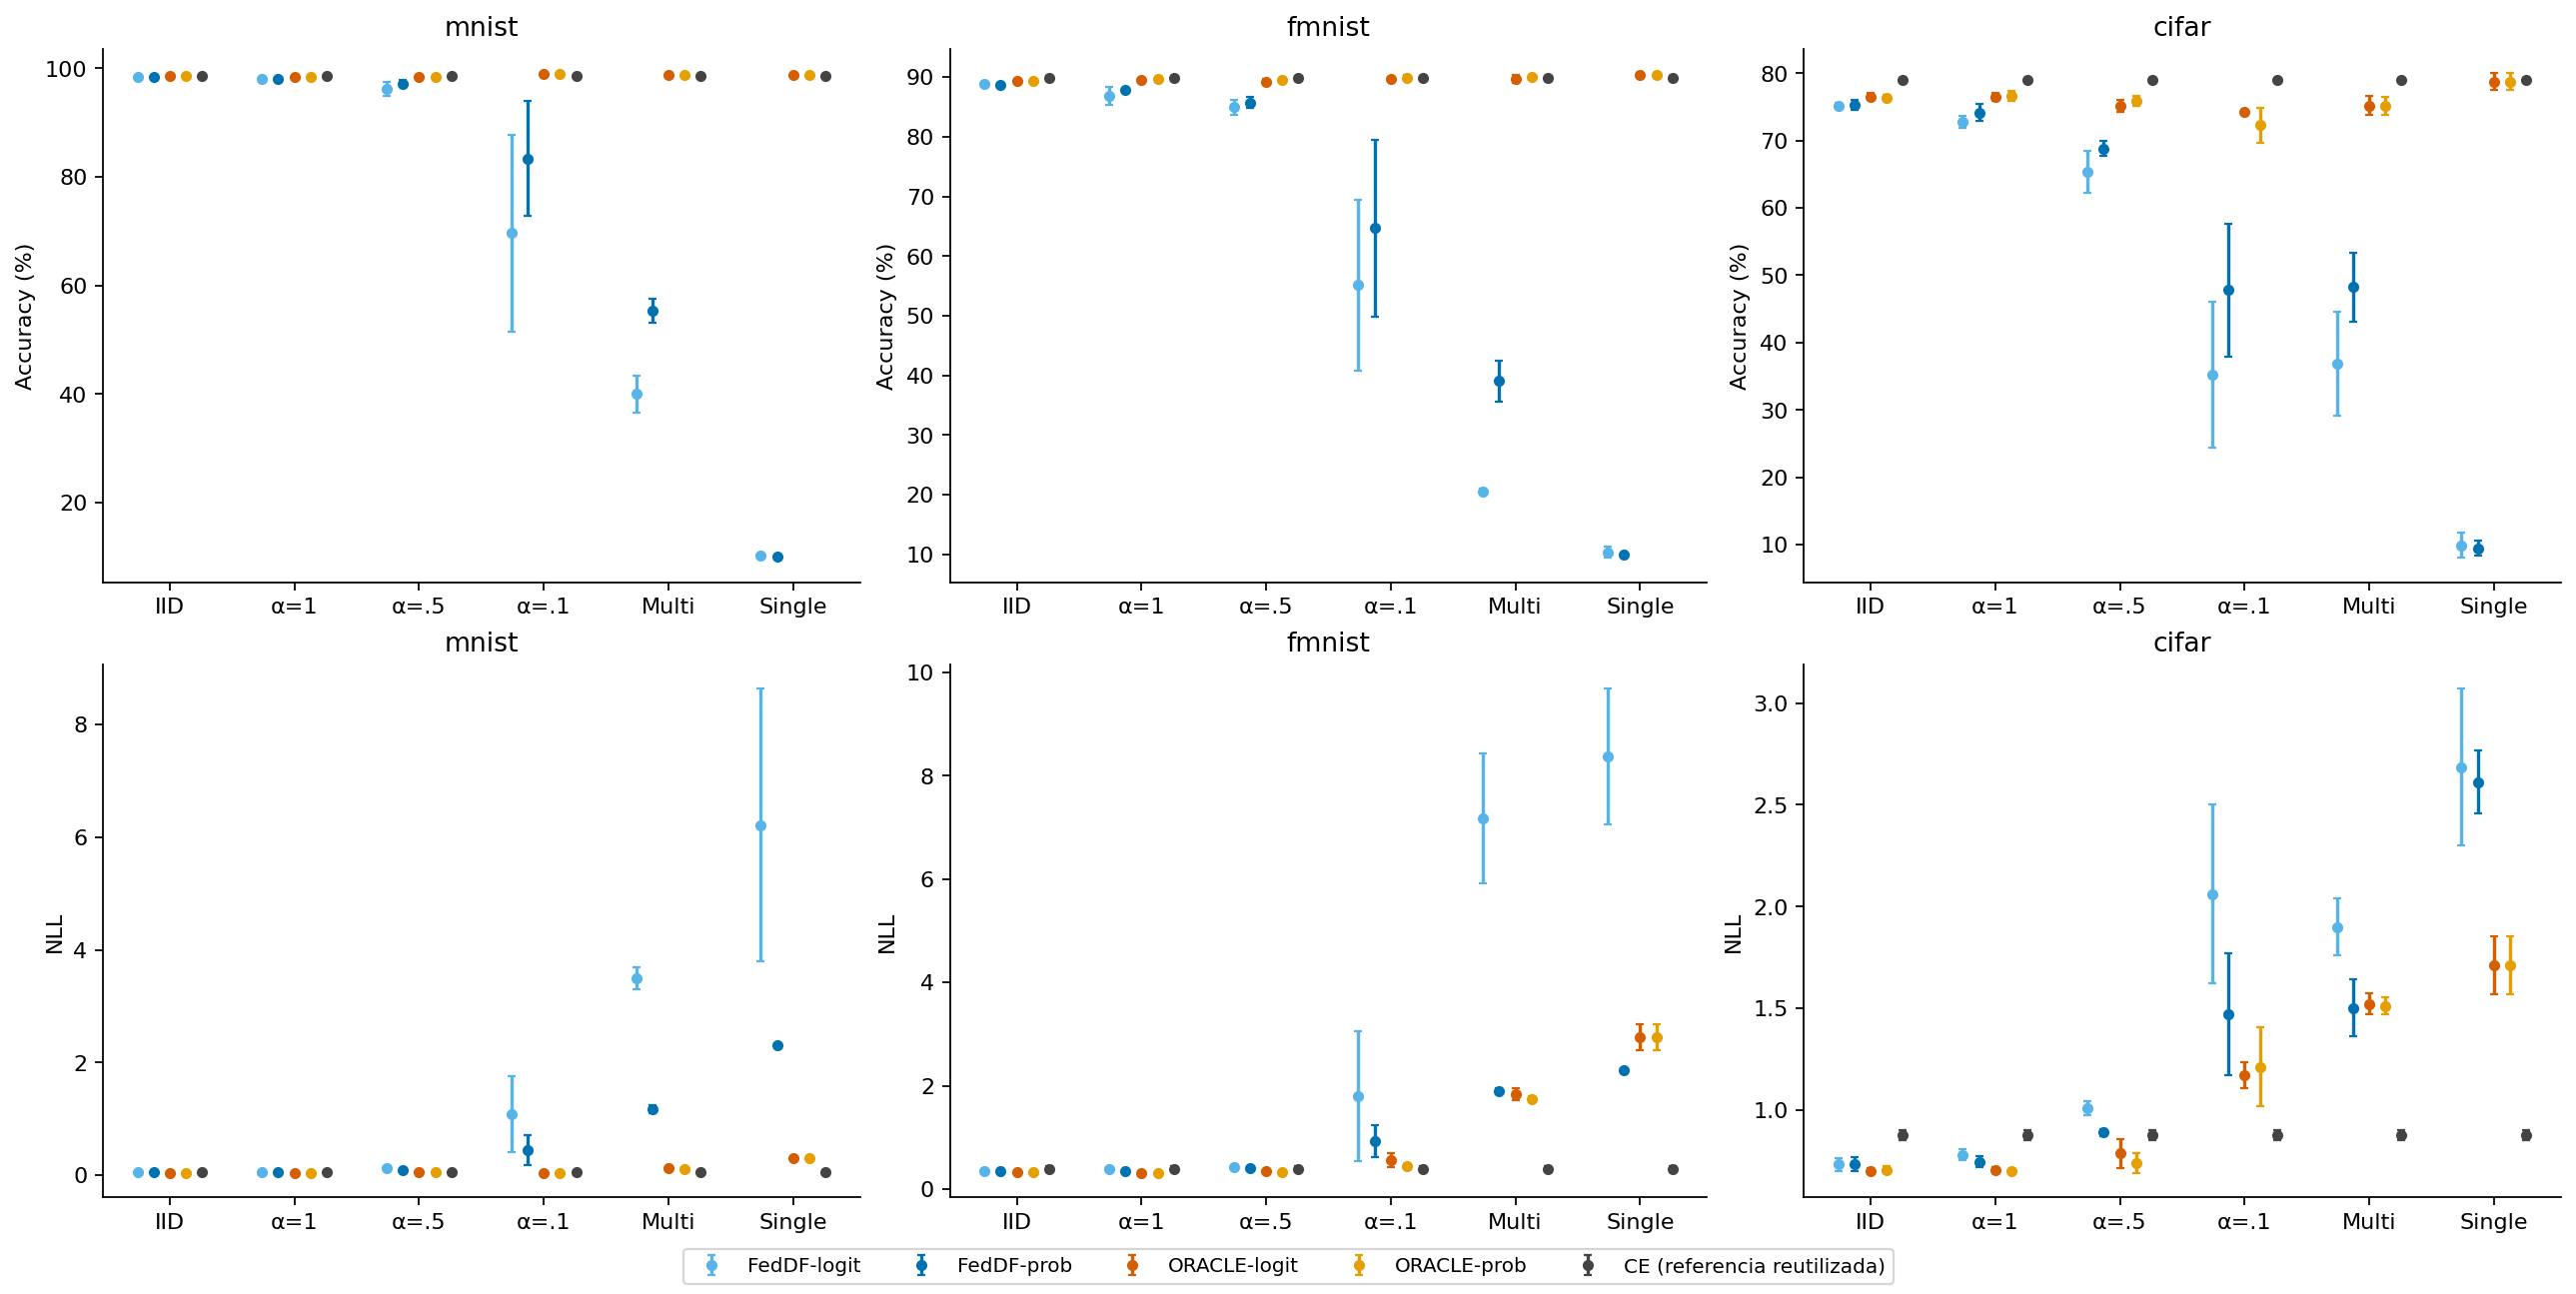

*Student en test oficial T=1, N=10000: media ± SD entre seeds; cobertura y seeds exactas en absolute.csv. CE tiene nueve ejecuciones únicas reutilizadas entre regímenes. No se selecciona la mejor variante retrospectivamente.*

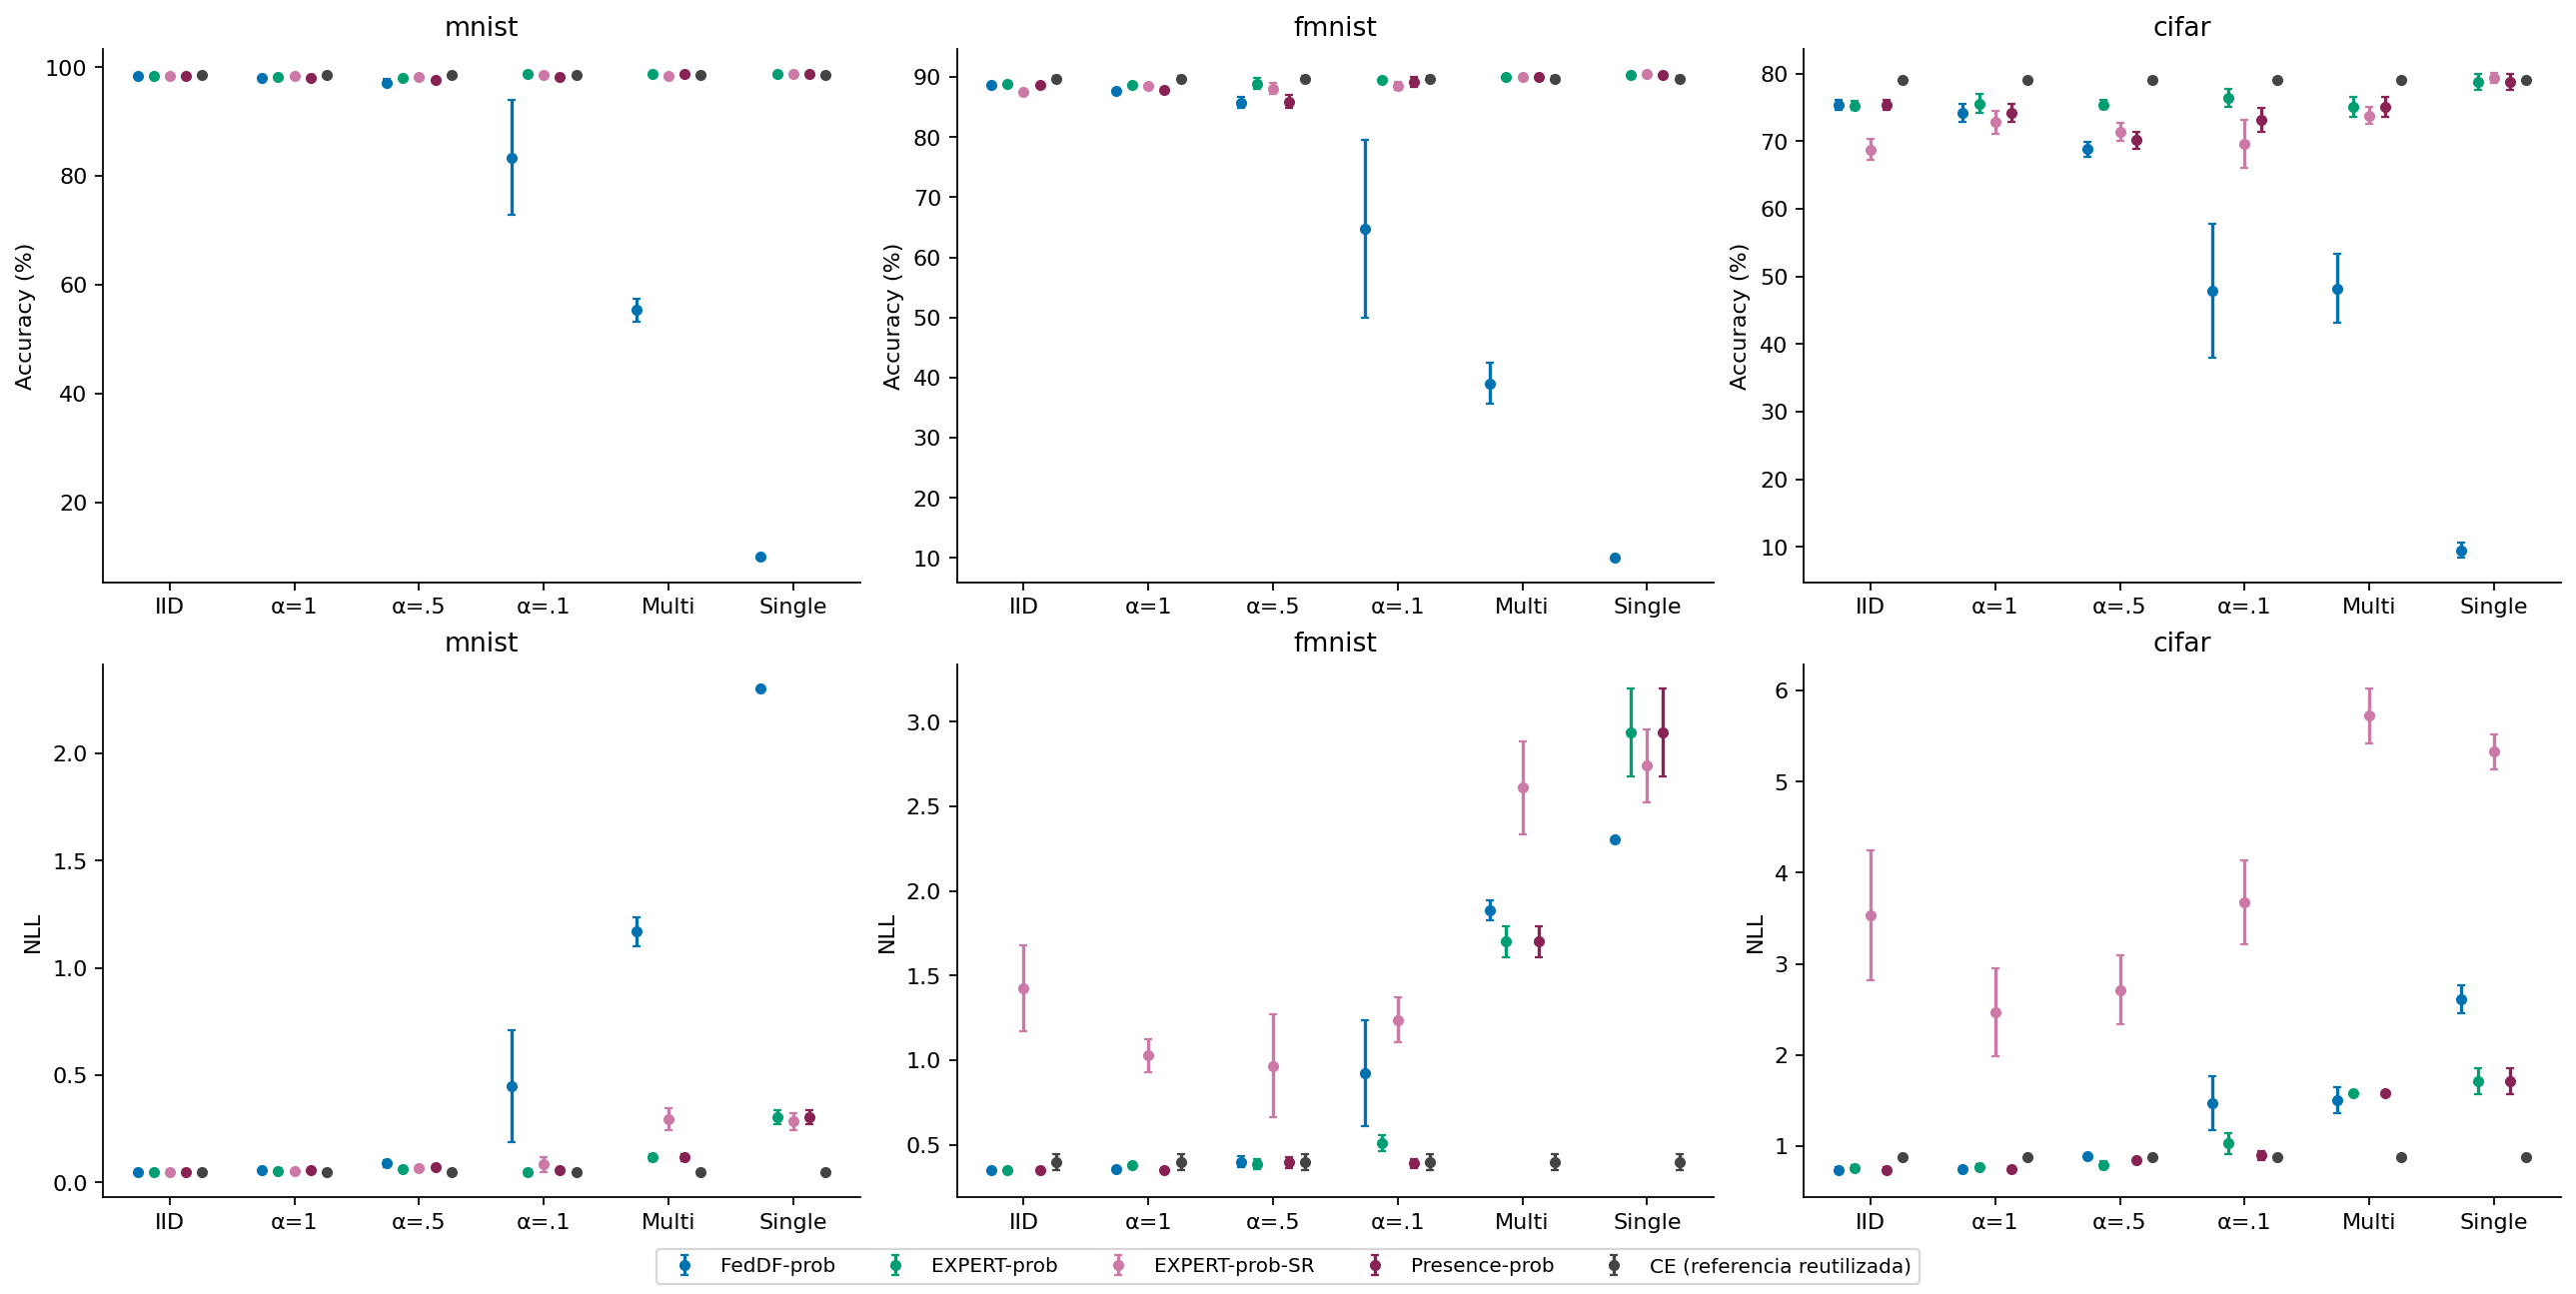

*Student en test oficial T=1, N=10000: media ± SD entre seeds; cobertura y seeds exactas en absolute.csv. CE tiene nueve ejecuciones únicas reutilizadas entre regímenes. No se selecciona la mejor variante retrospectivamente.*

,dataset,regime,method,metric,mean,sd,n,seeds
0,mnist,iid,feddf_prob,student_test_accuracy,98.423333,0.122202,3,"42,43,44"
1,mnist,iid,feddf_prob,student_test_nll,0.050057,0.005168,3,"42,43,44"
2,mnist,iid,expert_prob,student_test_accuracy,98.423333,0.122202,3,"42,43,44"
3,mnist,iid,expert_prob,student_test_nll,0.049895,0.004888,3,"42,43,44"
4,mnist,iid,expert_prob_sr,student_test_accuracy,98.423333,0.122202,3,"42,43,44"
...,...,...,...,...,...,...,...,...
419,mnist,single,supervised_proxy_ce,student_test_nll,0.049377,0.006223,3,"42,43,44"
420,fmnist,single,supervised_proxy_ce,student_test_accuracy,89.773333,0.360046,3,"42,43,44"
421,fmnist,single,supervised_proxy_ce,student_test_nll,0.396273,0.046189,3,"42,43,44"
422,cifar,single,supervised_proxy_ce,student_test_accuracy,79.013333,0.339460,3,"42,43,44"


In [4]:
show("overview_references")
show("overview_ablations")
display(pd.read_csv(OUT / "tables/absolute.csv"))

## B. Quién contribuye y qué aporta medir competencia

Contrastes de signo explícito: `selection` = ORACLE-logit − FedDF-logit; `expertise` = EXPERT-prob − FedDF-prob; `oracle_expert` = ORACLE-prob − EXPERT-prob; `competence_presence` = EXPERT-prob − presence-prob.

El último evalúa la acreditación frente al simple conocimiento de presencia en train. No aísla un efecto exclusivo de estimar calidad: también puede cambiar el número de teachers seleccionados. Los cambios de fallback implican cambios opuestos de cobertura del proxy; se muestran junto al número de participantes. ORACLE no es una cota garantizada.

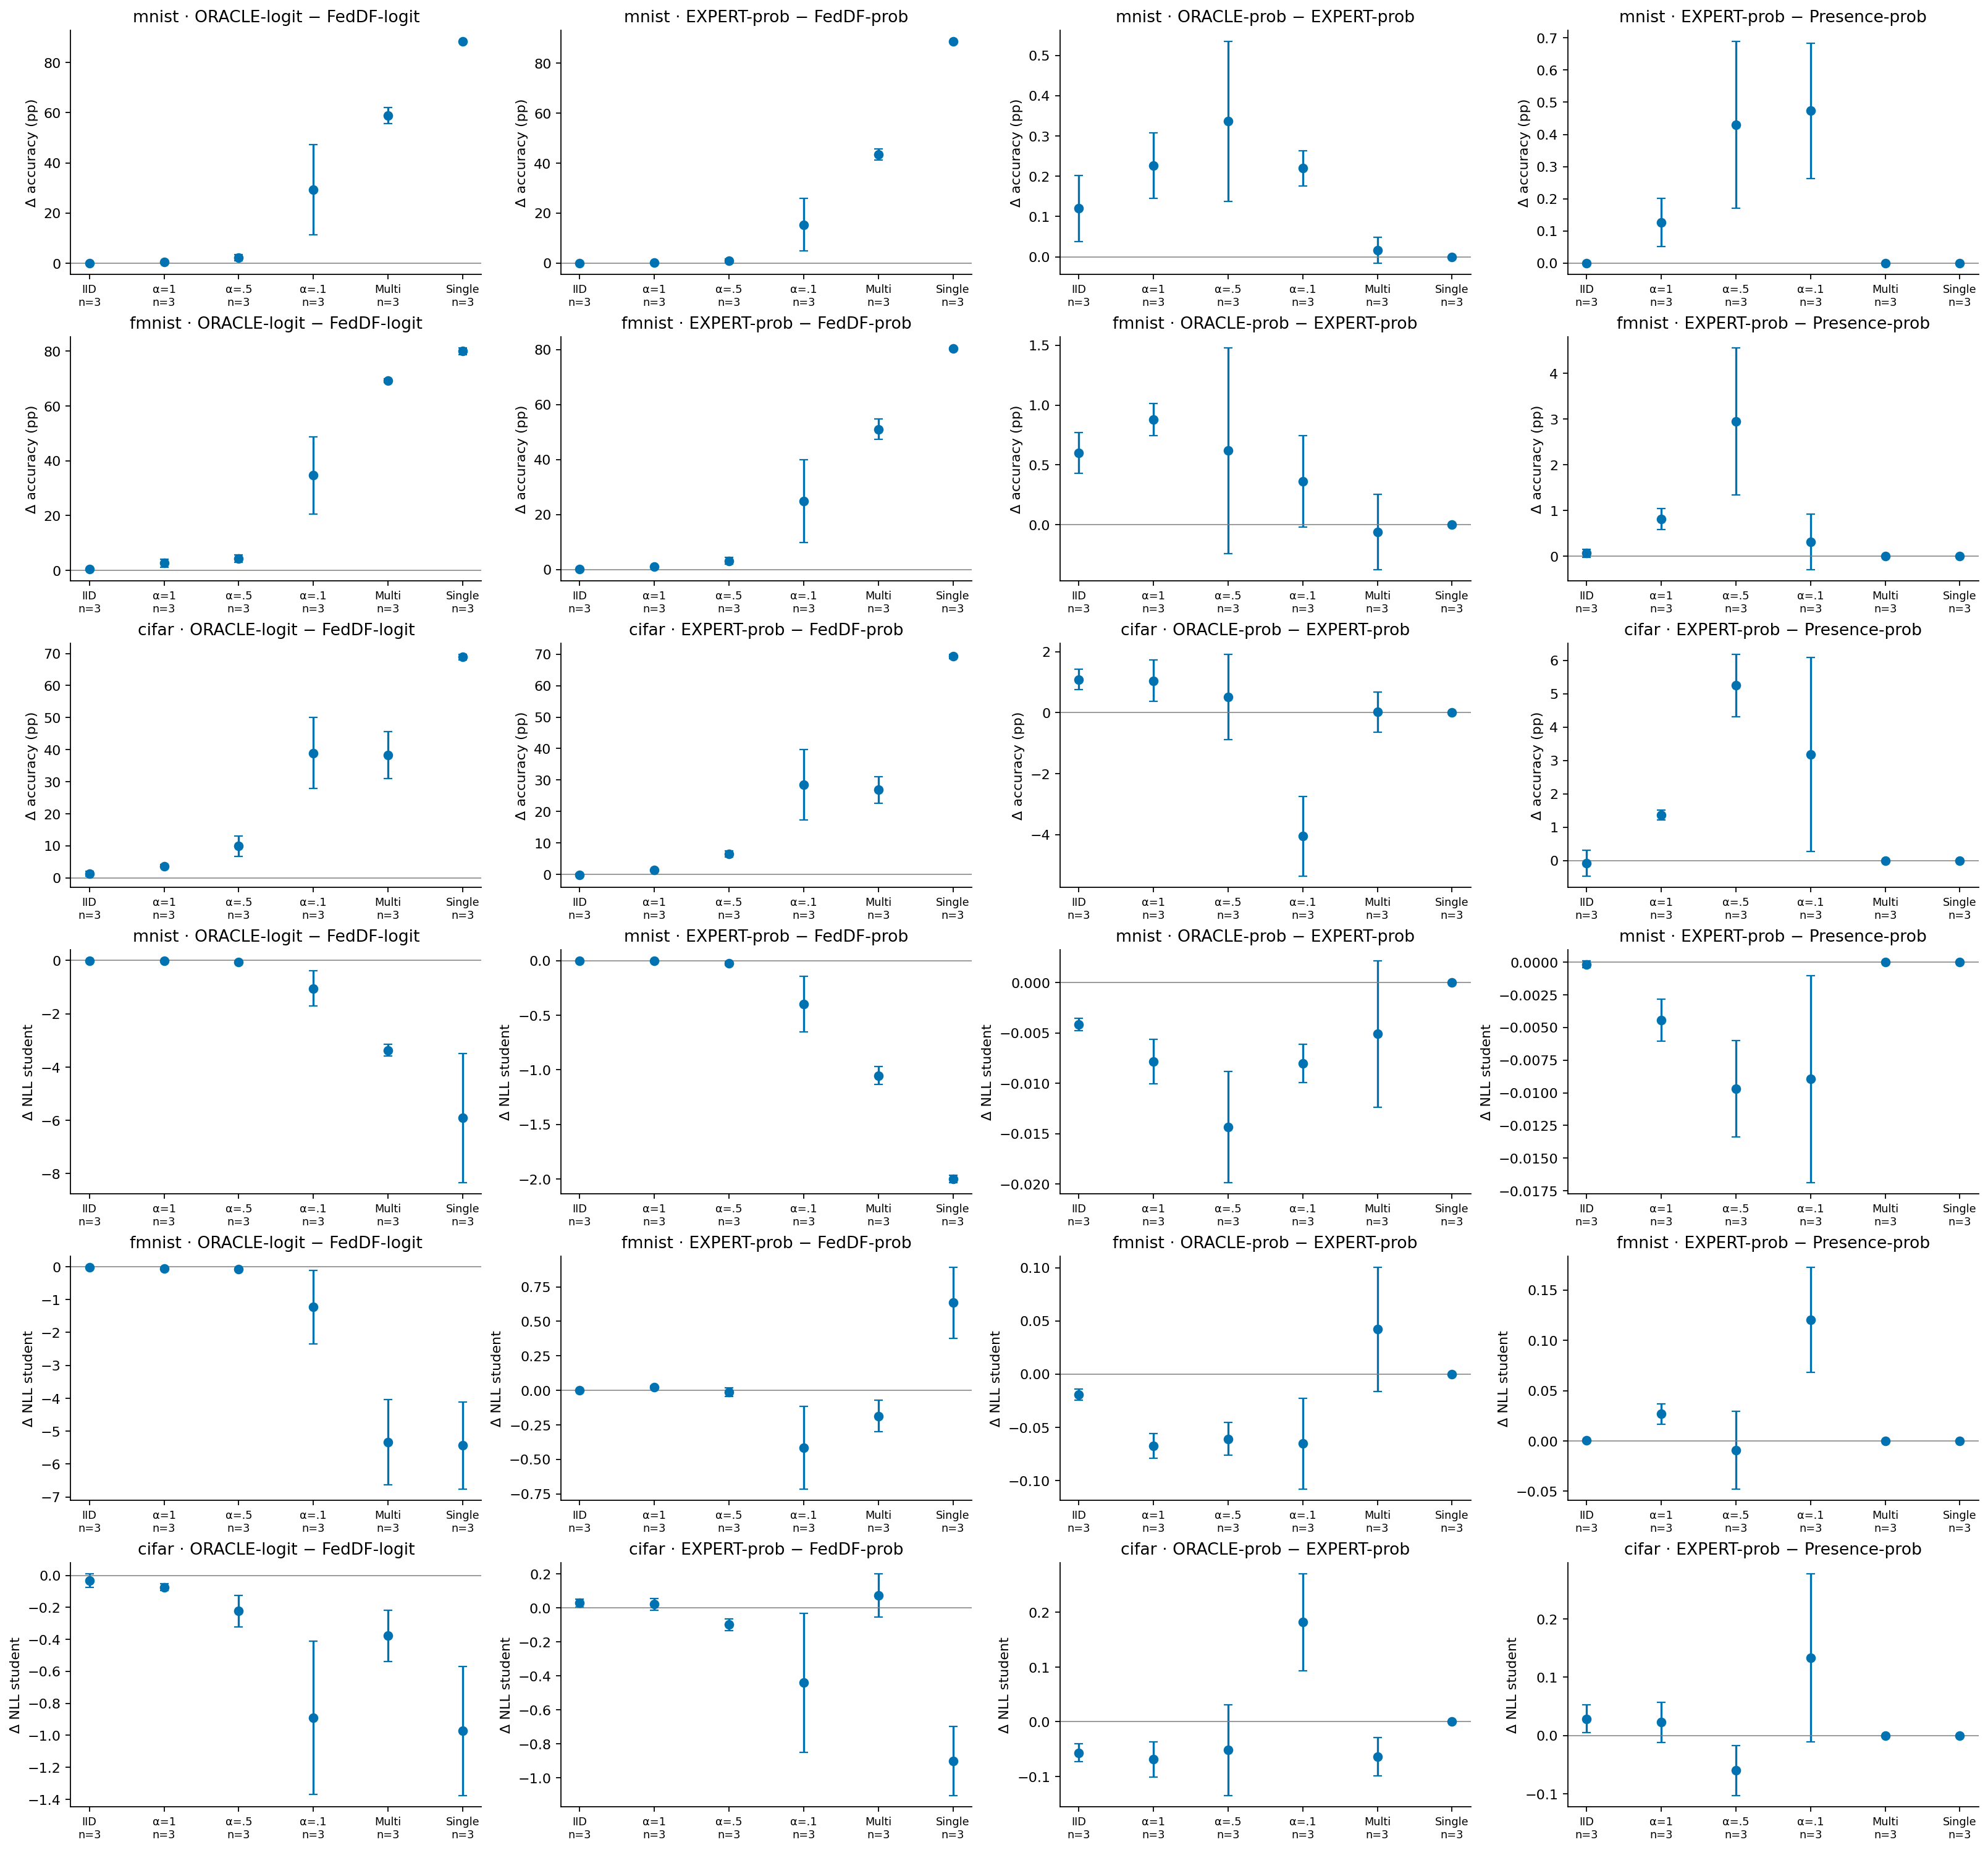

*Diferencias dentro de seed, después media ± SD. Signo: primer método menos segundo; accuracy en pp, NLL menor es mejor. n indica seeds válidas; eje categórico sin distancias experimentales iguales. Tres seeds limitan la inferencia.*

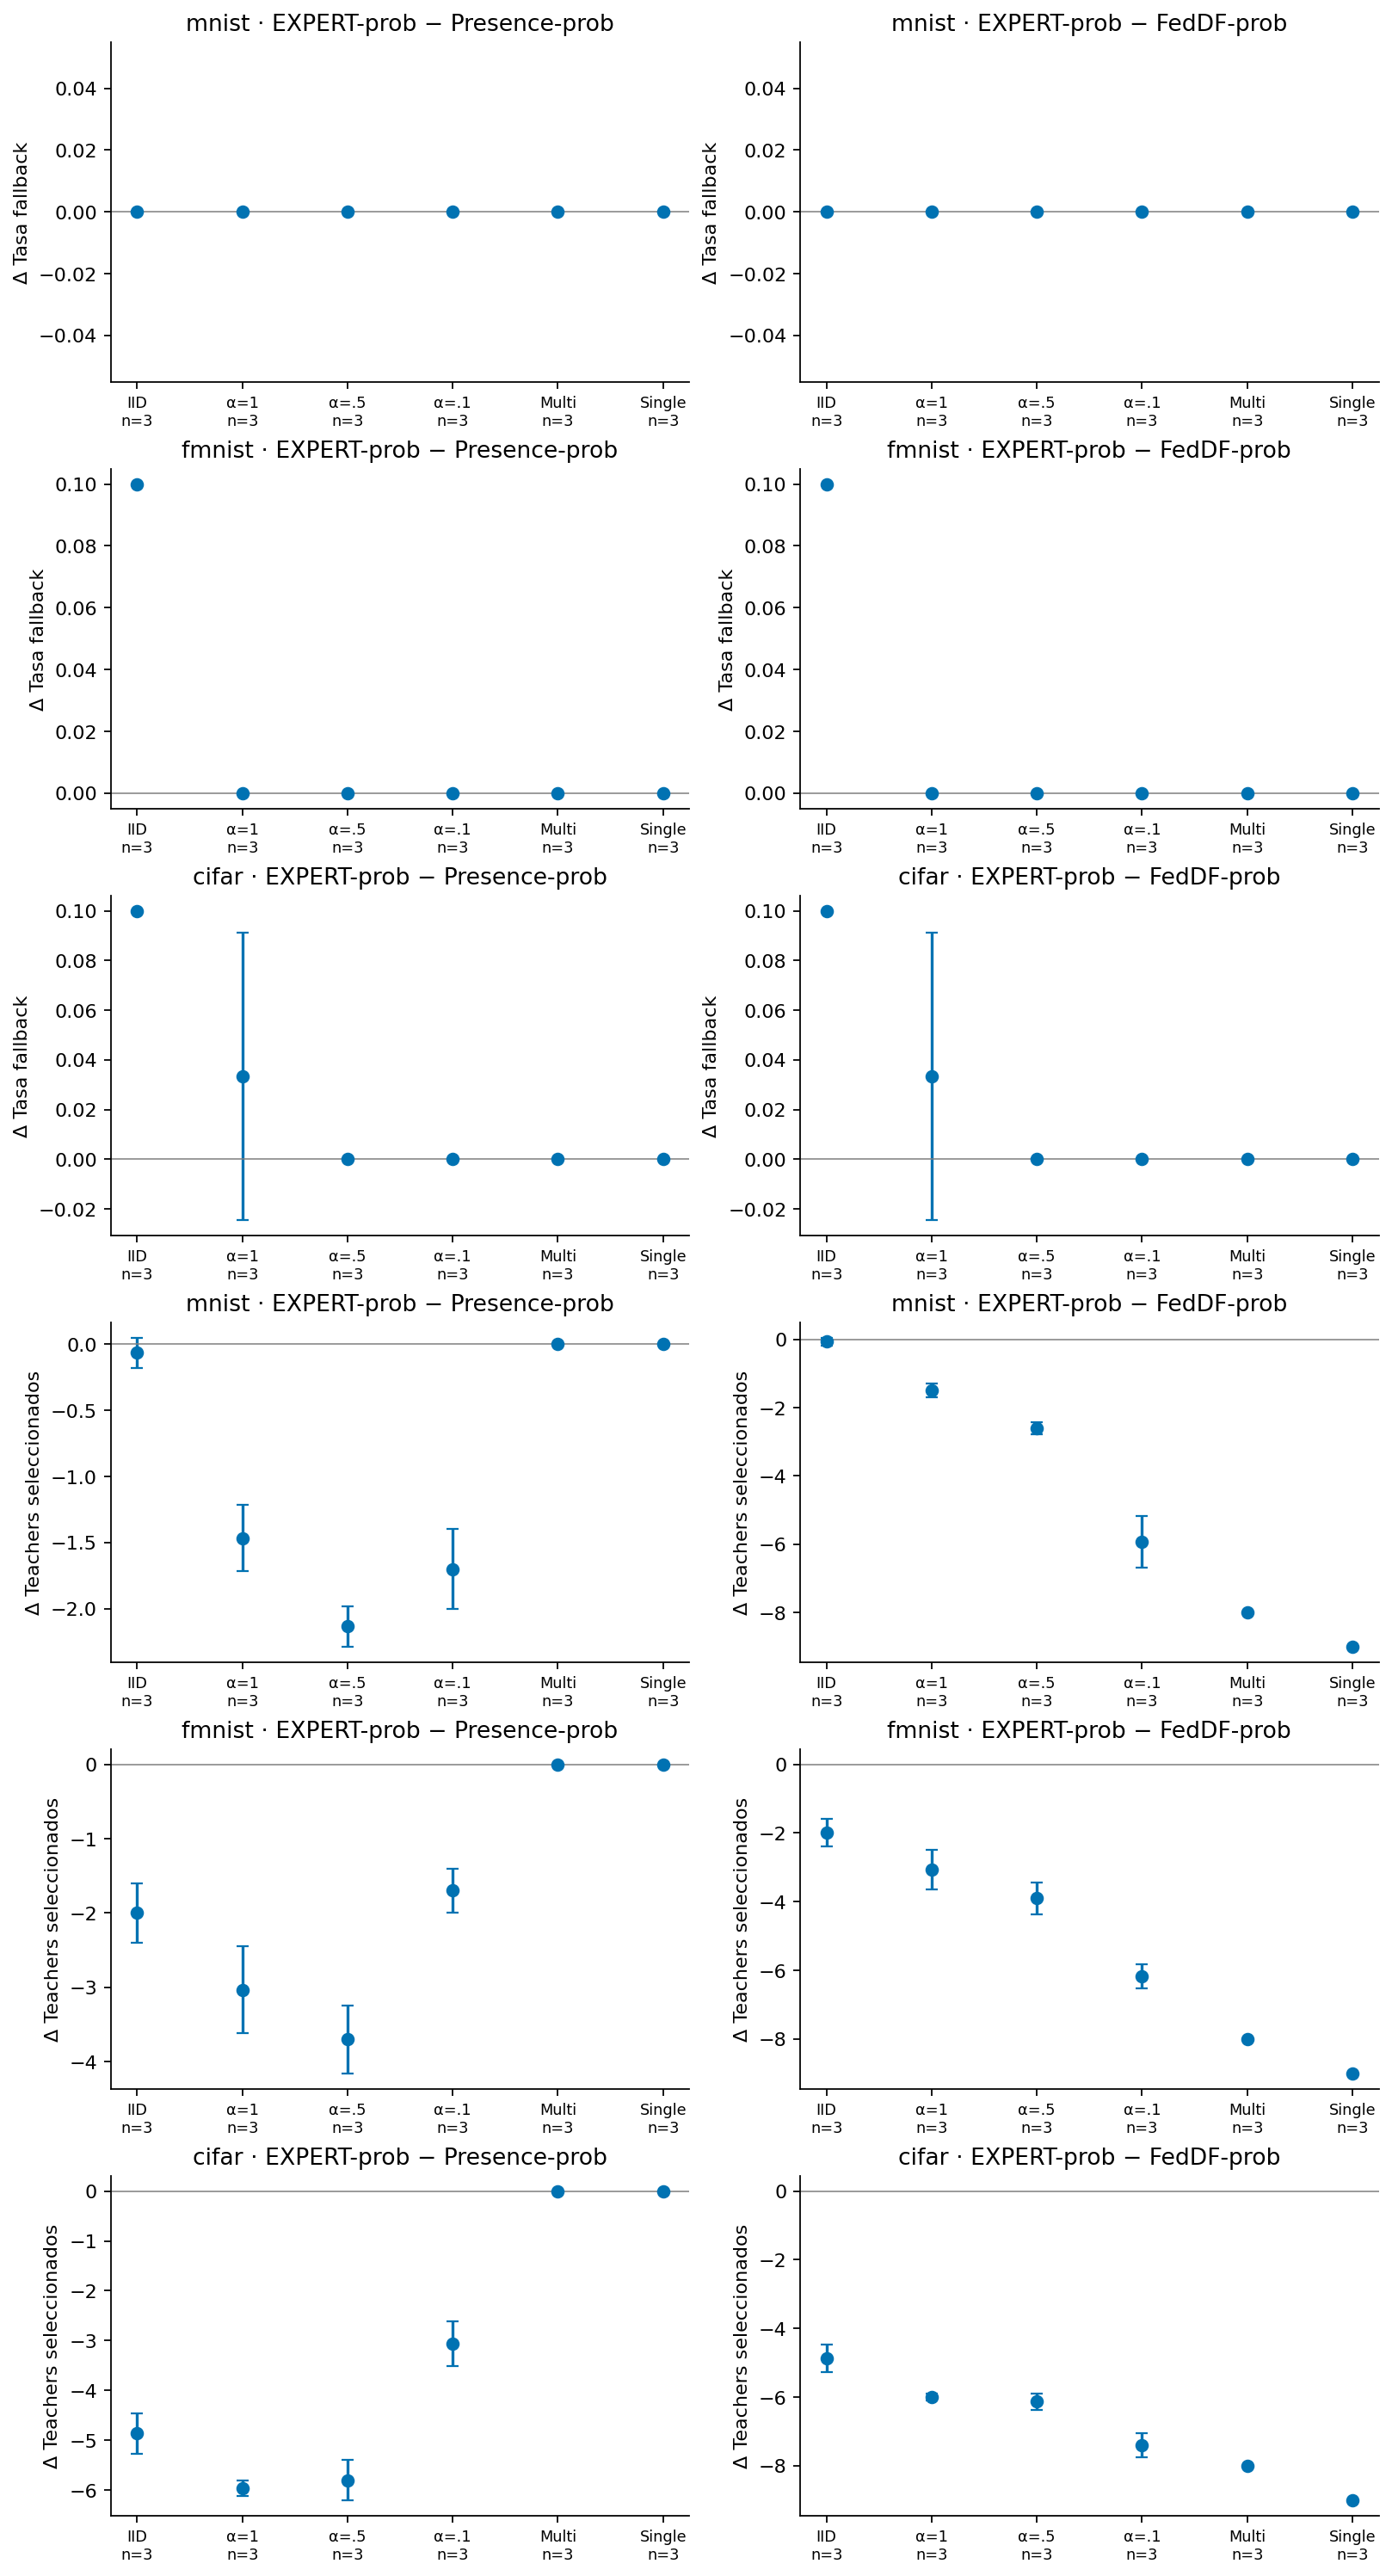

*Diferencias dentro de seed, después media ± SD. Signo: primer método menos segundo; accuracy en pp, NLL menor es mejor. n indica seeds válidas; eje categórico sin distancias experimentales iguales. Tres seeds limitan la inferencia.*

,contrast,dataset,positive_accuracy_regimes,negative_accuracy_regimes,negative_nll_regimes,accuracy_min_pp,accuracy_max_pp,complete_regimes
0,competence_presence,cifar,"alpha0p1,alpha0p5,alpha1p0",iid,alpha0p5,-0.076667,5.246667,6
1,competence_presence,fmnist,"alpha0p1,alpha0p5,alpha1p0,iid",,alpha0p5,0.000000,2.950000,6
2,competence_presence,mnist,"alpha0p1,alpha0p5,alpha1p0",,"alpha0p1,alpha0p5,alpha1p0,iid",0.000000,0.473333,6
6,expertise,cifar,"alpha0p1,alpha0p5,alpha1p0,multi,single",iid,"alpha0p1,alpha0p5,single",-0.076667,69.286667,6
7,expertise,fmnist,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single",,"alpha0p1,alpha0p5,multi",0.066667,80.296667,6
8,expertise,mnist,"alpha0p1,alpha0p5,alpha1p0,multi,single",,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single",0.000000,88.730000,6
12,oracle_expert,cifar,"alpha0p5,alpha1p0,iid,multi",alpha0p1,"alpha0p5,alpha1p0,iid,multi",-4.056667,1.086667,6
13,oracle_expert,fmnist,"alpha0p1,alpha0p5,alpha1p0,iid",multi,"alpha0p1,alpha0p5,alpha1p0,iid",-0.060000,0.876667,6
14,oracle_expert,mnist,"alpha0p1,alpha0p5,alpha1p0,iid,multi",,"alpha0p1,alpha0p5,alpha1p0,iid,multi",0.000000,0.336667,6
24,selection,cifar,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single",,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single",1.346667,68.886667,6


In [5]:
show("selection_competence", 1600)
show("routing")
display(findings[findings.contrast.isin(["selection","expertise","oracle_expert","competence_presence"])])

## C. Espacio de agregación

`pooling_feddf` = FedDF-prob − FedDF-logit; `pooling_oracle` = ORACLE-prob − ORACLE-logit; `pooling_expert` = EXPERT-prob − EXPERT-logit. Los pares exigen routing compartido. La comparación EXPERT utiliza únicamente el respaldo compatible, sin completar los huecos del grid. La tabla indica n y seeds para cada condición; no se extiende una conclusión a condiciones ausentes. Diferencias pequeñas no prueban equivalencia. Las temperaturas adicionales solo se analizarían con ejecuciones verificadas; su disponibilidad real aparece en el inventario.

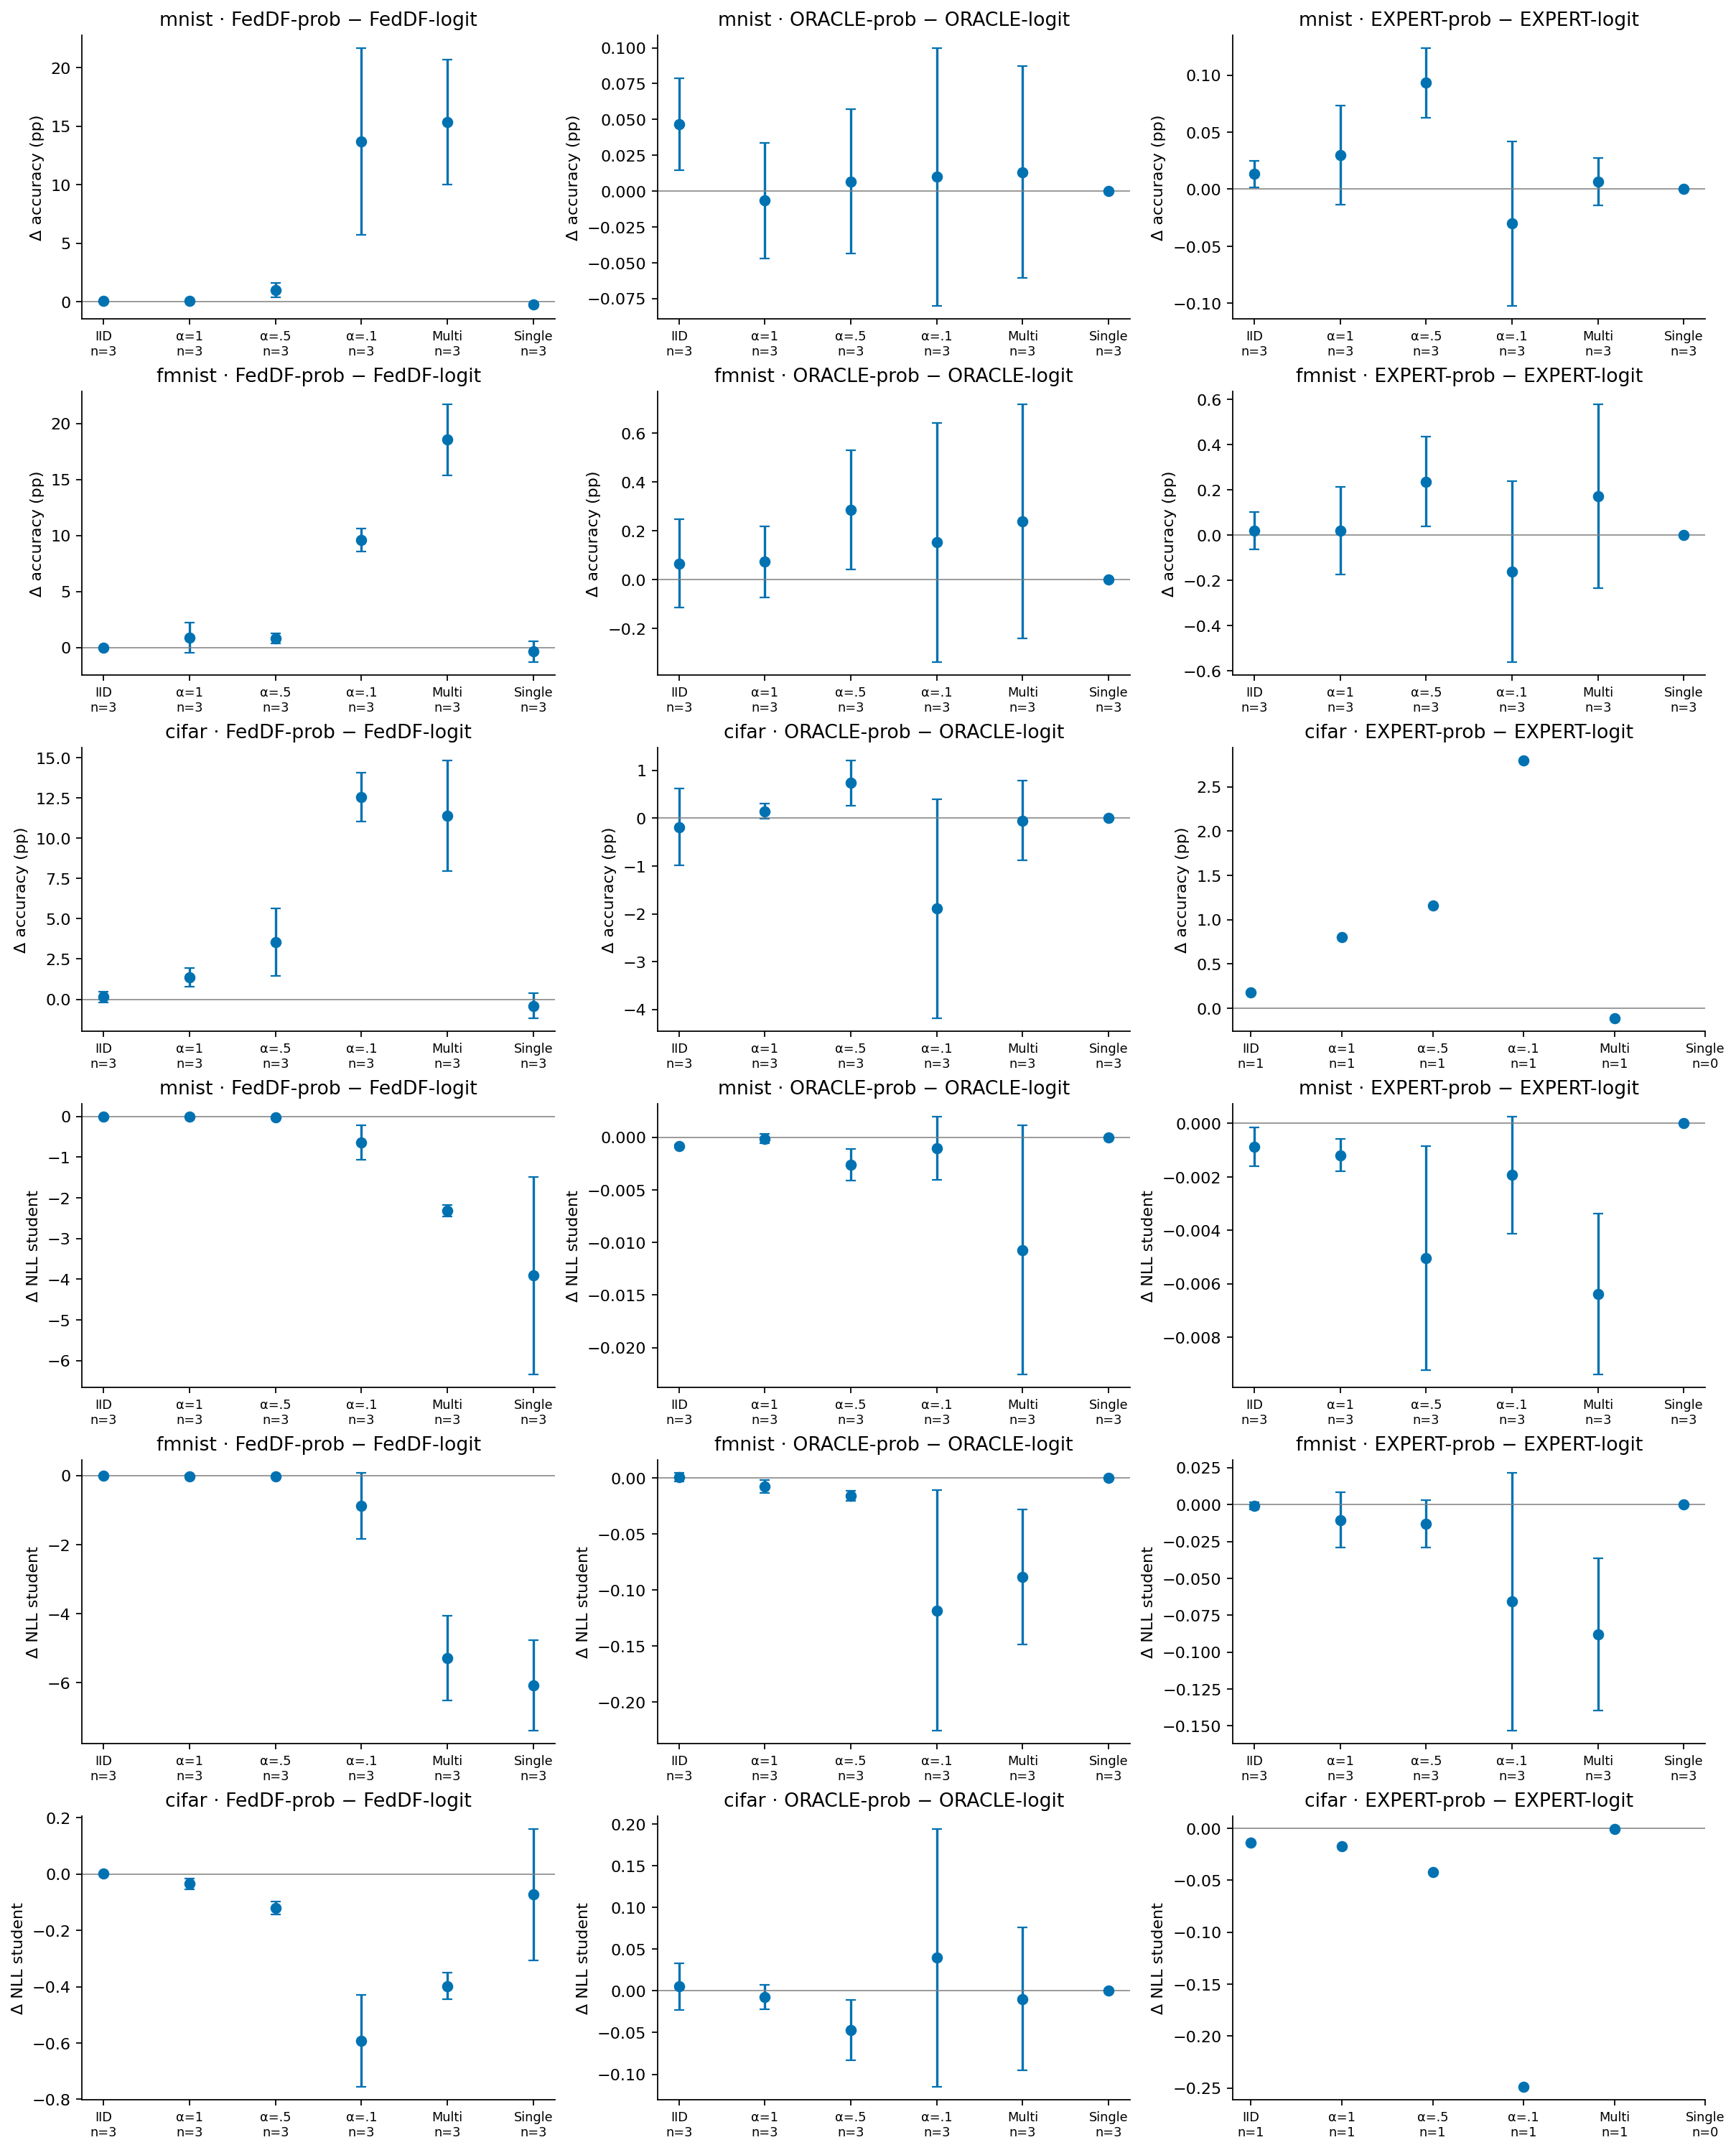

*Diferencias dentro de seed, después media ± SD. Signo: primer método menos segundo; accuracy en pp, NLL menor es mejor. n indica seeds válidas; eje categórico sin distancias experimentales iguales. Tres seeds limitan la inferencia.*

,dataset,regime,metric,mean,sd,n,seeds,contrast
648,cifar,alpha0p1,delta_student_test_accuracy,12.543333,1.511633,3,"42,43,44",pooling_feddf
649,cifar,alpha0p1,delta_student_test_nll,-0.592261,0.162455,3,"42,43,44",pooling_feddf
650,cifar,alpha0p1,delta_target_accuracy,15.176667,1.313634,3,"42,43,44",pooling_feddf
651,cifar,alpha0p1,delta_target_nll,-0.131887,0.010171,3,"42,43,44",pooling_feddf
652,cifar,alpha0p1,delta_target_entropy,-0.013320,0.005928,3,"42,43,44",pooling_feddf
...,...,...,...,...,...,...,...,...
1120,mnist,single,delta_target_entropy,0.000000,0.000000,3,"42,43,44",pooling_expert
1121,mnist,single,delta_fallback_count,0.000000,0.000000,3,"42,43,44",pooling_expert
1122,mnist,single,delta_fallback_rate,0.000000,0.000000,3,"42,43,44",pooling_expert
1123,mnist,single,delta_mean_selected_teachers,0.000000,0.000000,3,"42,43,44",pooling_expert


In [6]:
show("aggregation_space", 1500)
display(analysis["contrasts"][analysis["contrasts"].contrast.str.startswith("pooling")])

## D. Target frente a student y restricción de soporte

El contraste es siempre **SR − EXPERT completo**. Se presentan accuracy, NLL y entropía del target sobre proxy a T=8 y accuracy/NLL del student sobre test oficial a T=1. No se interpreta la diferencia de niveles absolutos como gap de generalización.

Ambos brazos comparten routing y masa previa. `pre_restriction_outside_support_mass` se recalcula desde caches y máscaras verificados cuando no está persistida: es el promedio de masa externa sobre eventos **teacher/muestra seleccionados**, excluyendo fallback; no necesariamente el promedio por muestra de masa eliminada del ensemble. IID no implica M completo ni masa externa cero.

Para cada teacher seleccionado, M contiene la etiqueta proxy verdadera. Renormalizar su distribución sobre ese soporte no reduce la probabilidad de dicha etiqueta; el fallback es idéntico. Por ello el NLL del target no aumenta (salvo tolerancia numérica). Esta propiedad algebraica no garantiza mejorar el student. SR cambia a la vez información interclase y concentración: su efecto no demuestra por sí solo destrucción de dark knowledge. Controlar entropía/concentración manteniendo soporte completo sigue siendo trabajo futuro.

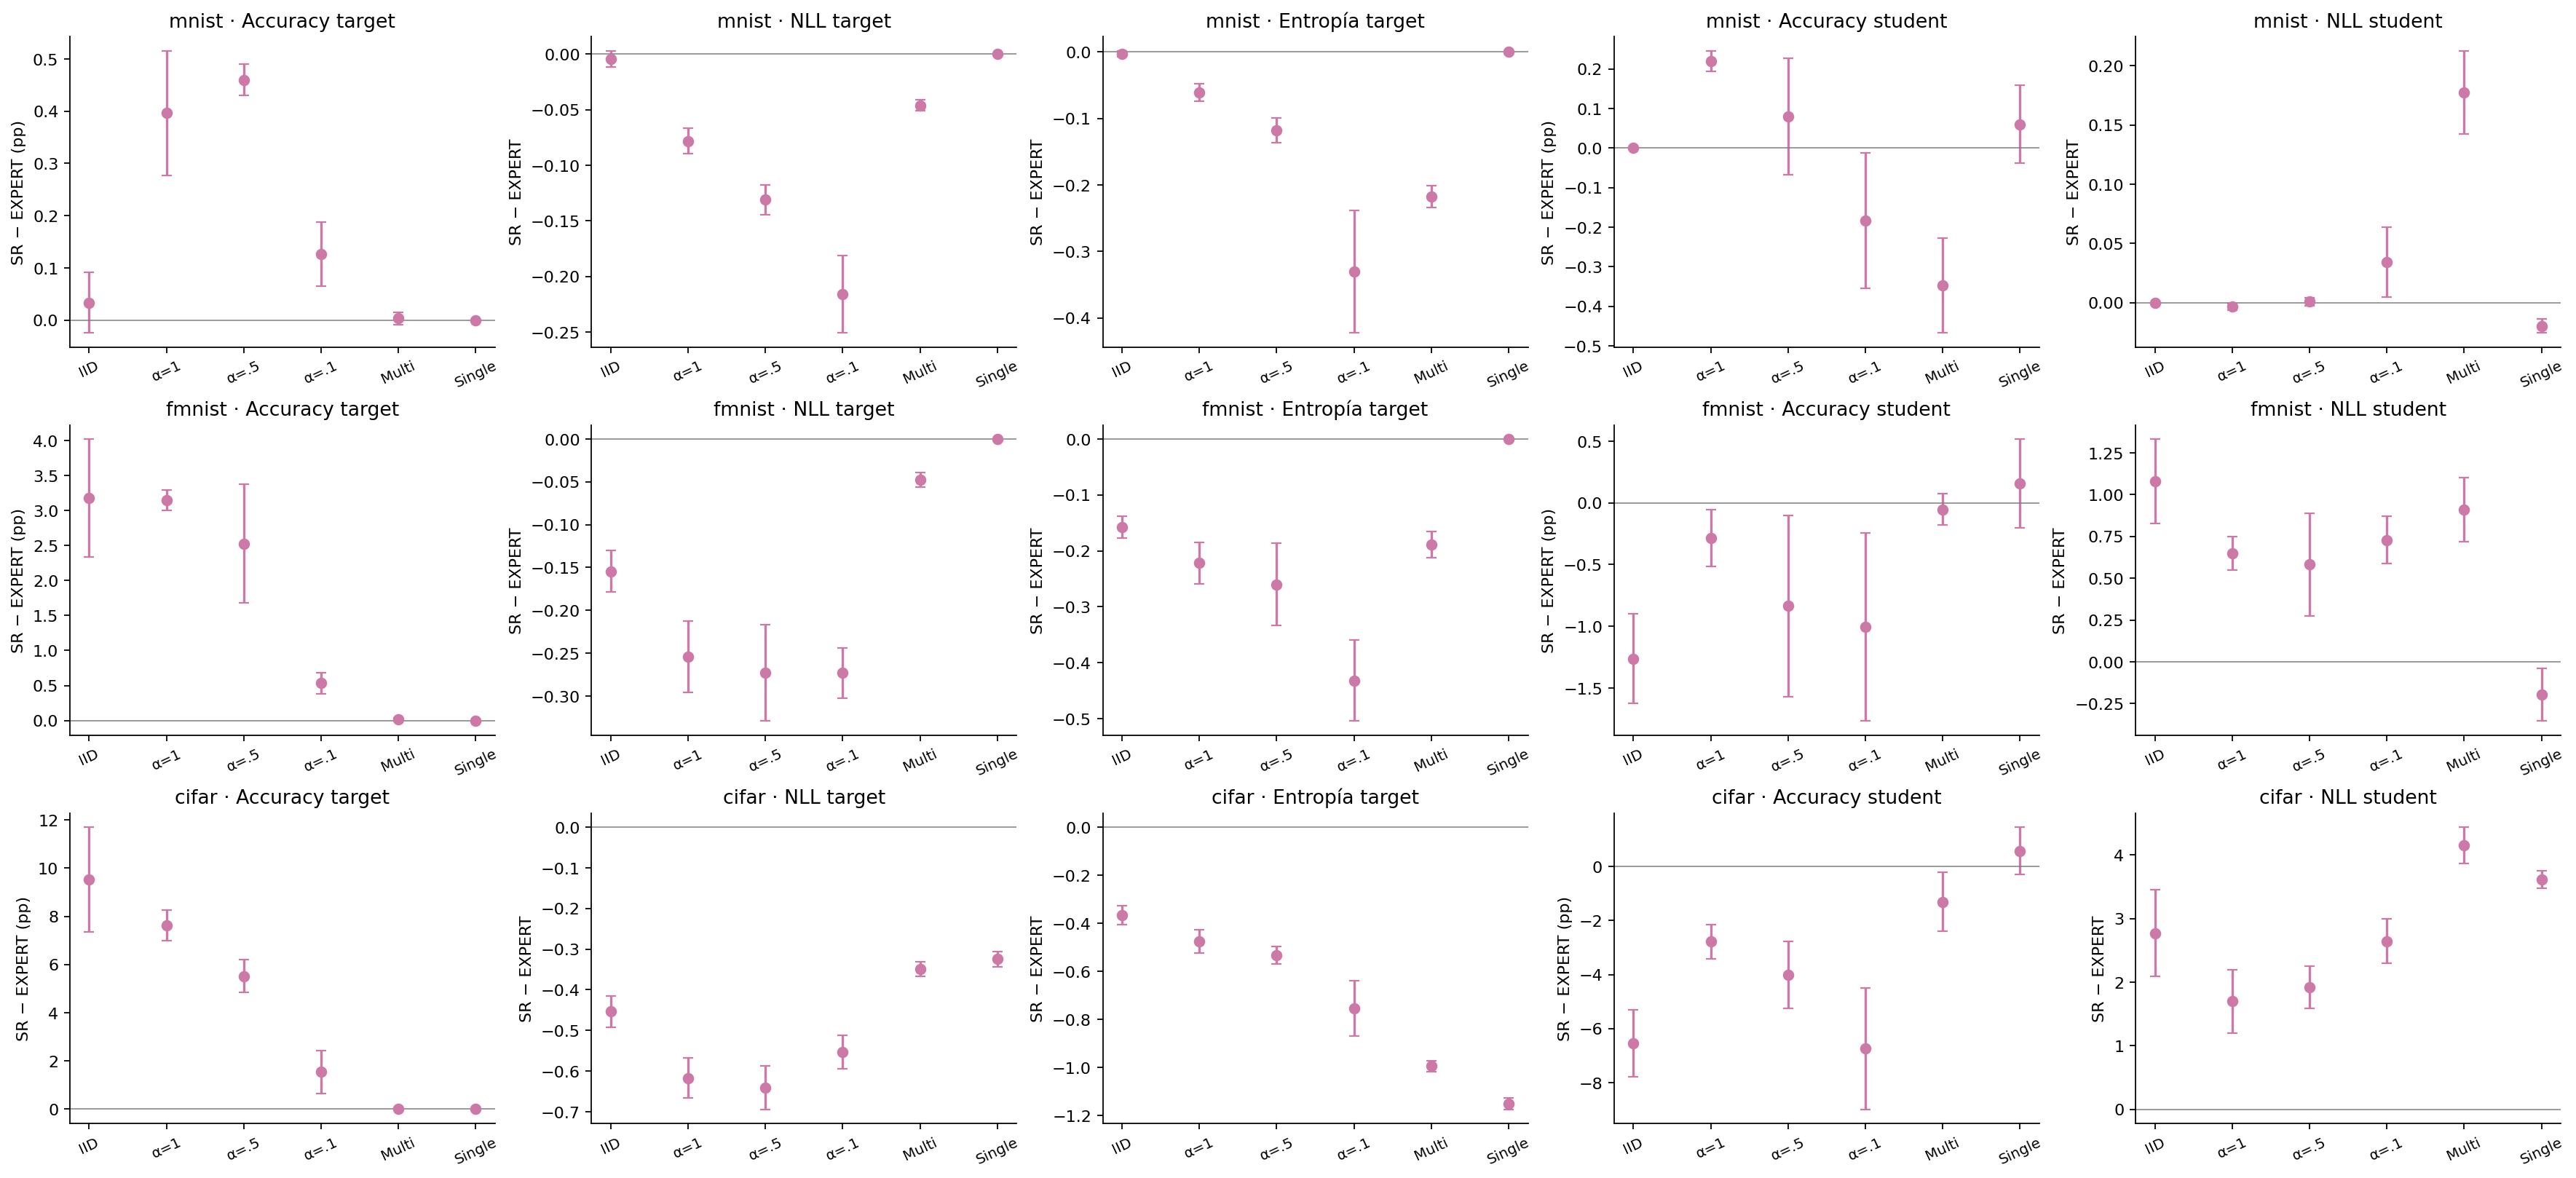

*SR − EXPERT completo; media ± SD de diferencias emparejadas. Target: proxy a T=8; student: test oficial a T=1. Sus niveles absolutos no definen un gap de generalización. Routing y masa previa compartidos; target NLL no aumenta por renormalización sobre soporte que contiene la etiqueta verdadera.*

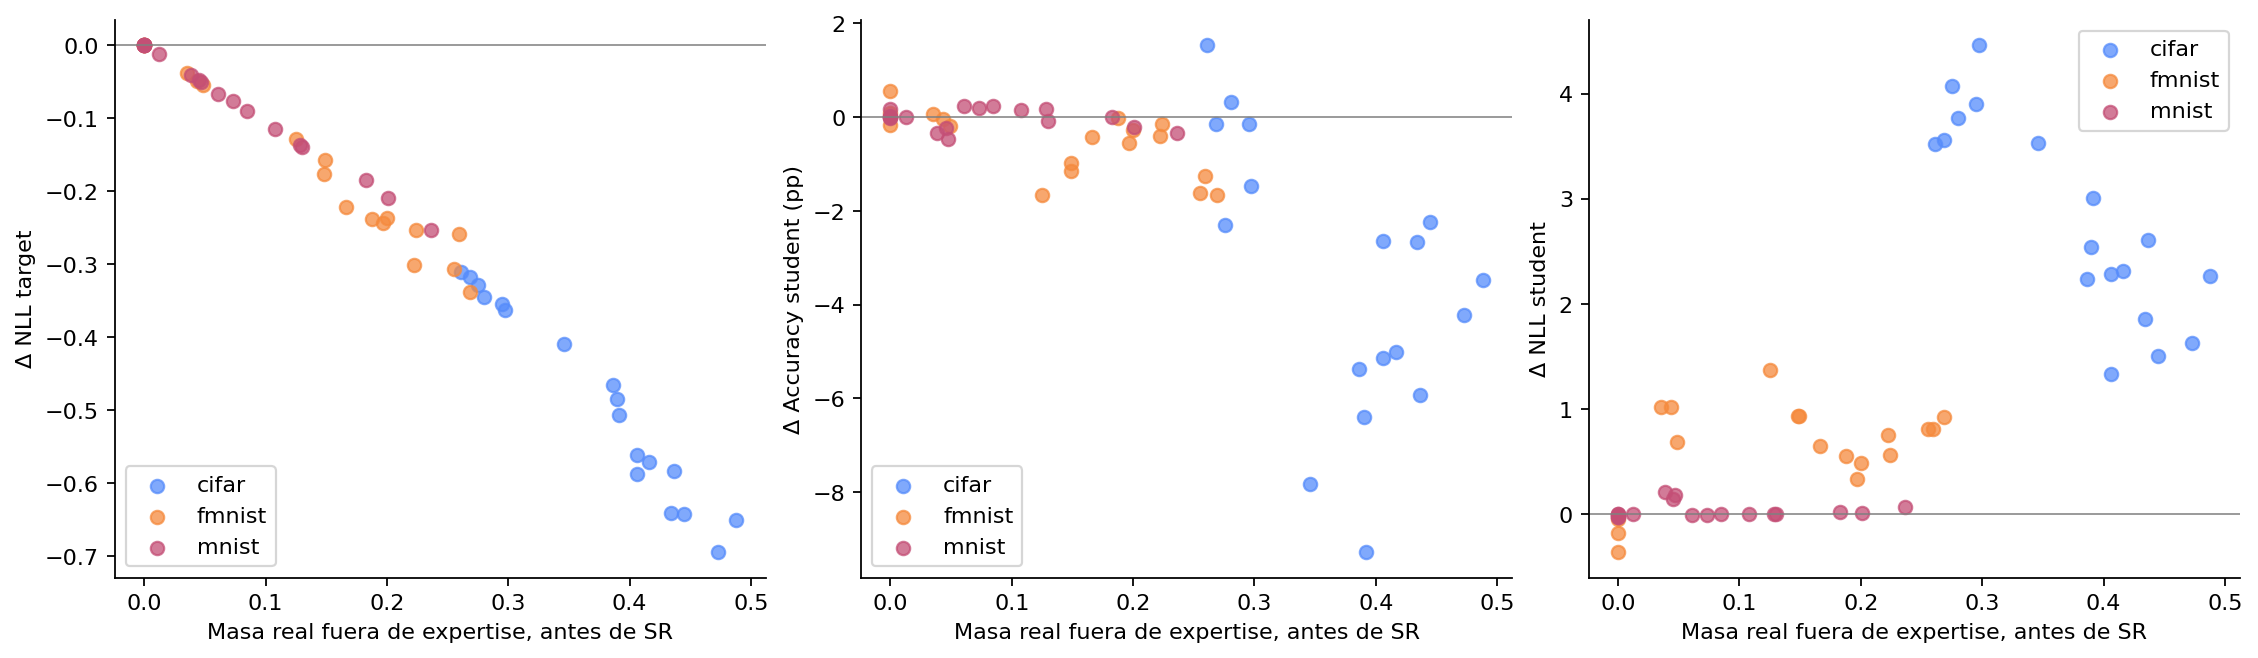

*Cada punto es una condición/seed. Masa promedio sobre eventos teacher/muestra seleccionados, excluyendo fallback; no necesariamente masa eliminada del ensemble por muestra. Asociación descriptiva; no demuestra destrucción de dark knowledge.*

,dataset,regime,metric,mean,sd,n,seeds,contrast
1125,cifar,alpha0p1,delta_student_test_accuracy,-6.743333,2.243442,3,"42,43,44",support
1126,cifar,alpha0p1,delta_student_test_nll,2.644705,0.349276,3,"42,43,44",support
1127,cifar,alpha0p1,delta_target_accuracy,1.533333,0.892711,3,"42,43,44",support
1128,cifar,alpha0p1,delta_target_nll,-0.553553,0.041147,3,"42,43,44",support
1129,cifar,alpha0p1,delta_target_entropy,-0.754278,0.114129,3,"42,43,44",support
...,...,...,...,...,...,...,...,...
1282,mnist,single,delta_target_entropy,-0.000038,0.000012,3,"42,43,44",support
1283,mnist,single,delta_fallback_count,0.000000,0.000000,3,"42,43,44",support
1284,mnist,single,delta_fallback_rate,0.000000,0.000000,3,"42,43,44",support
1285,mnist,single,delta_mean_selected_teachers,0.000000,0.000000,3,"42,43,44",support


,contrast,dataset,positive_accuracy_regimes,negative_accuracy_regimes,negative_nll_regimes,accuracy_min_pp,accuracy_max_pp,complete_regimes
27,support,cifar,single,"alpha0p1,alpha0p5,alpha1p0,iid,multi",,-6.743333,0.573333,6
28,support,fmnist,single,"alpha0p1,alpha0p5,alpha1p0,iid,multi",single,-1.263333,0.156667,6
29,support,mnist,"alpha0p5,alpha1p0,single","alpha0p1,multi","alpha1p0,iid,single",-0.346667,0.220000,6


Pares con aumento NLL target > 1e-9: 0
Pares con mejora accuracy student: 12 / 54
Pares con menor NLL student: 11 / 54


mean           std           min       max
dataset regime                                                  
cifar   alpha0p1  0.414795  2.241231e-02  3.916034e-01  0.436337
        alpha0p5  0.437598  3.371099e-02  4.058696e-01  0.472992
        alpha1p0  0.446448  4.092289e-02  4.062778e-01  0.488084
        iid       0.374052  2.435800e-02  3.460113e-01  0.389971
        multi     0.289277  1.201640e-02  2.754433e-01  0.297121
        single    0.270040  9.671326e-03  2.613232e-01  0.280444
fmnist  alpha0p1  0.246132  1.947907e-02  2.237346e-01  0.259121
        alpha0p5  0.221927  4.074135e-02  1.968732e-01  0.268937
        alpha1p0  0.192108  2.842998e-02  1.661343e-01  0.222481
        iid       0.140863  1.353890e-02  1.252322e-01  0.148927
        multi     0.042594  6.673756e-03  3.546730e-02  0.048696
        single    0.000004  6.421957e-07  2.784744e-06  0.000004
mnist   alpha0p1  0.206540  2.722039e-02  1.824866e-01  0.236089
        alpha0p5  0.122135  1.245132e-02  1.077922e-01  0.130169
        alpha1p0  0.072825  1.187716e-02  6.083527e-02  0.084586
        iid       0.004152  7.191547e-03  8.506529e-18  0.012456
        multi     0.043739  4.678022e-03  3.842116e-02  0.047219
        single    0.000003  1.002762e-06  1.769183e-06  0.000004

In [7]:
show("support_target_student", 1600)
show("support_mass")
sr = analysis["pairs"]["support"]
display(analysis["contrasts"][analysis["contrasts"].contrast.eq("support")])
display(findings[findings.contrast.eq("support")])
print("Pares con aumento NLL target > 1e-9:", int(sr.delta_target_nll.gt(1e-9).sum()))
print("Pares con mejora accuracy student:", int(sr.delta_student_test_accuracy.gt(0).sum()), "/", len(sr))
print("Pares con menor NLL student:", int(sr.delta_student_test_nll.lt(0).sum()), "/", len(sr))
display(pd.read_csv(OUT / "tables/support_mass_pairs.csv").groupby(["dataset","regime"])["pre_restriction_outside_support_mass"].agg(["mean","std","min","max"]))

## E. Etiquetas públicas y curva de N

Primero CE exclusivamente, con sus tres seeds y media. Después CE, EXPERT-prob y FedDF-prob en CIFAR-10, IID/α=.1/Single. Se reutilizan las anclas N=10000; ninguna aparición gráfica de CE añade evidencia independiente. Se muestran curvas absolutas y EXPERT − CE, FedDF − CE, EXPERT − FedDF.

El presupuesto fija **1200 actualizaciones**, no ejemplos consumidos. En N=100 el batch efectivo es 100; el resto usa hasta 256, con batches finales incompletos según N. Los subconjuntos son anidados dentro de seed y compartidos entre brazos. Cruces entre puntos evaluados no definen un N óptimo ni un umbral universal; las curvas solo abarcan CIFAR-10.

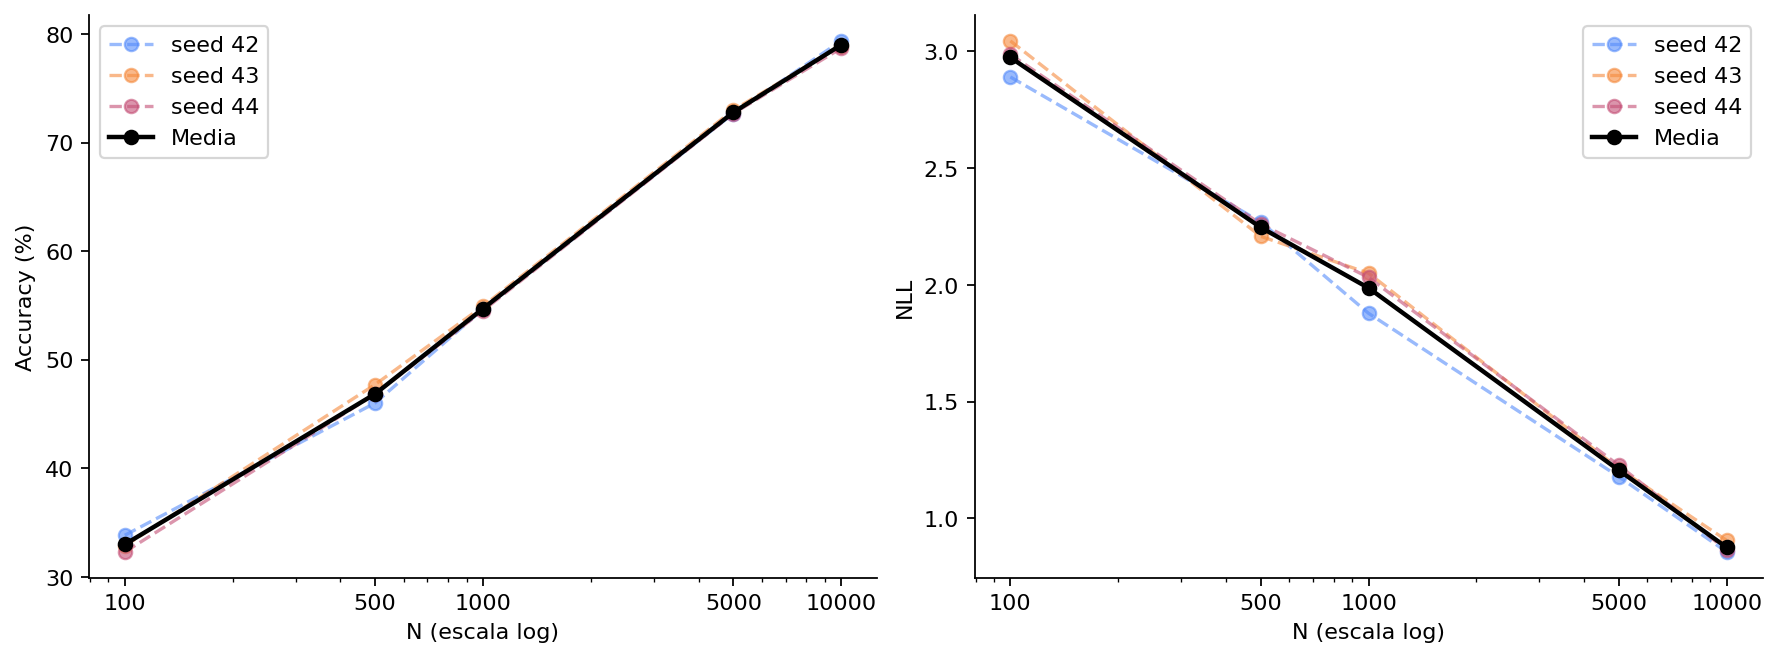

*Solo CE, CIFAR-10: tres seeds reales y su media, sin replicar regímenes. 1200 actualizaciones en todos los puntos; N=100 usa batch efectivo 100 y cambia ejemplos consumidos.*

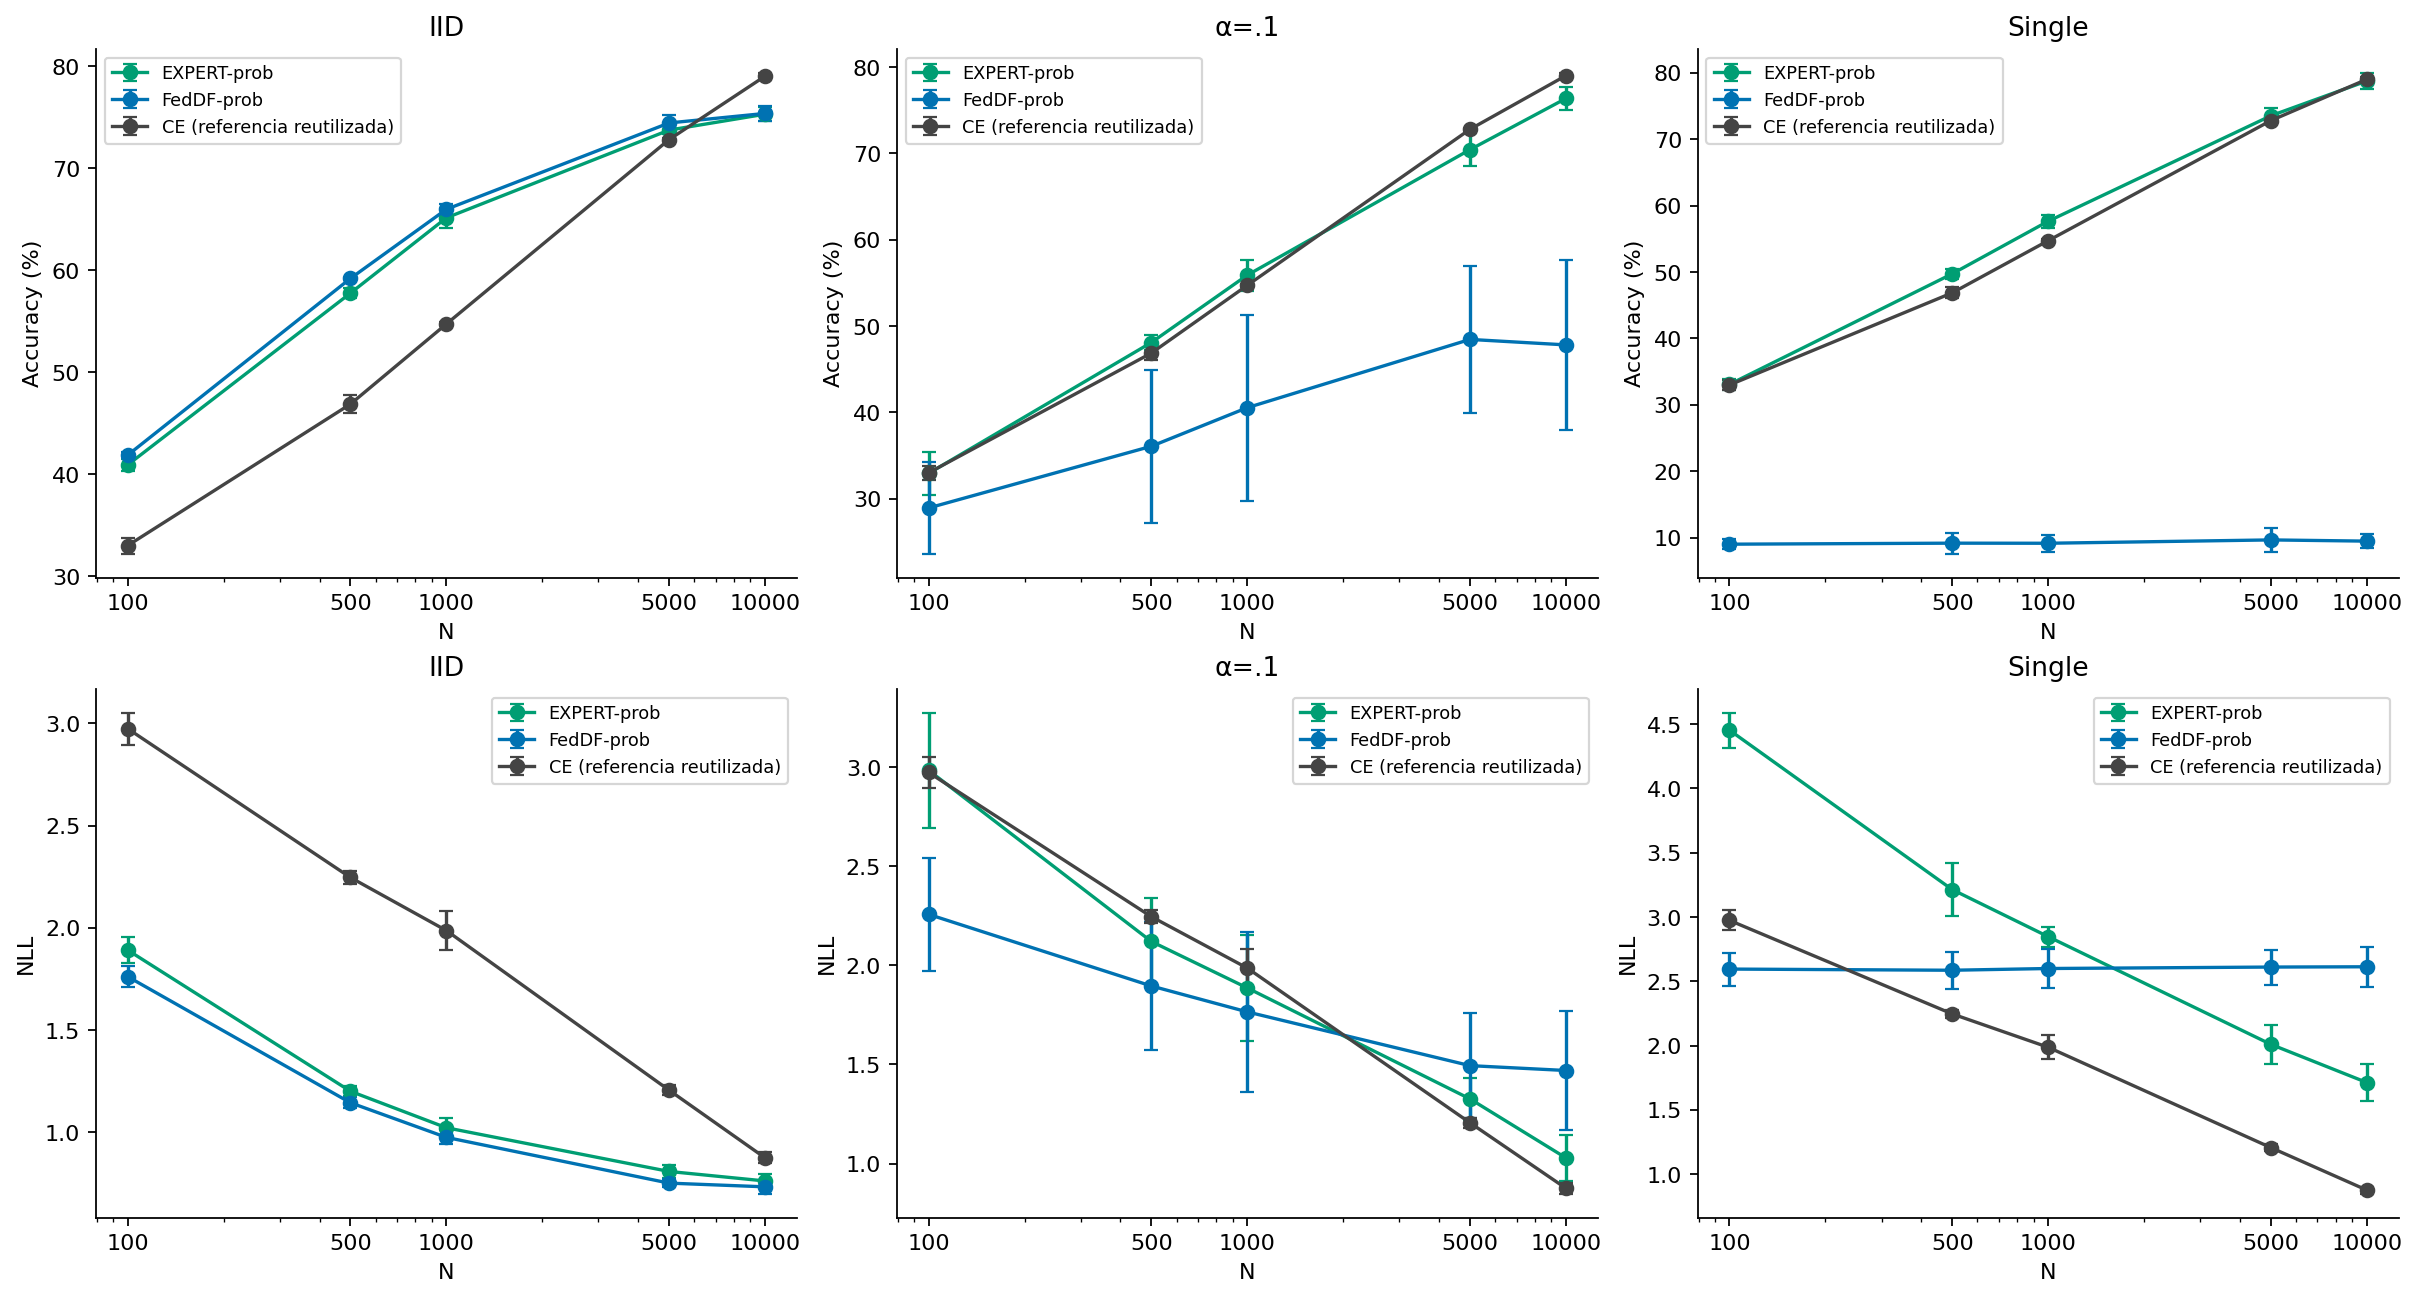

*CIFAR-10, tres seeds: media ± SD; anclas N=10000 reutilizadas del baseline. CE compartido entre regímenes. Subconjuntos anidados y trazas emparejadas verificadas; presupuesto de actualizaciones, no de ejemplos.*

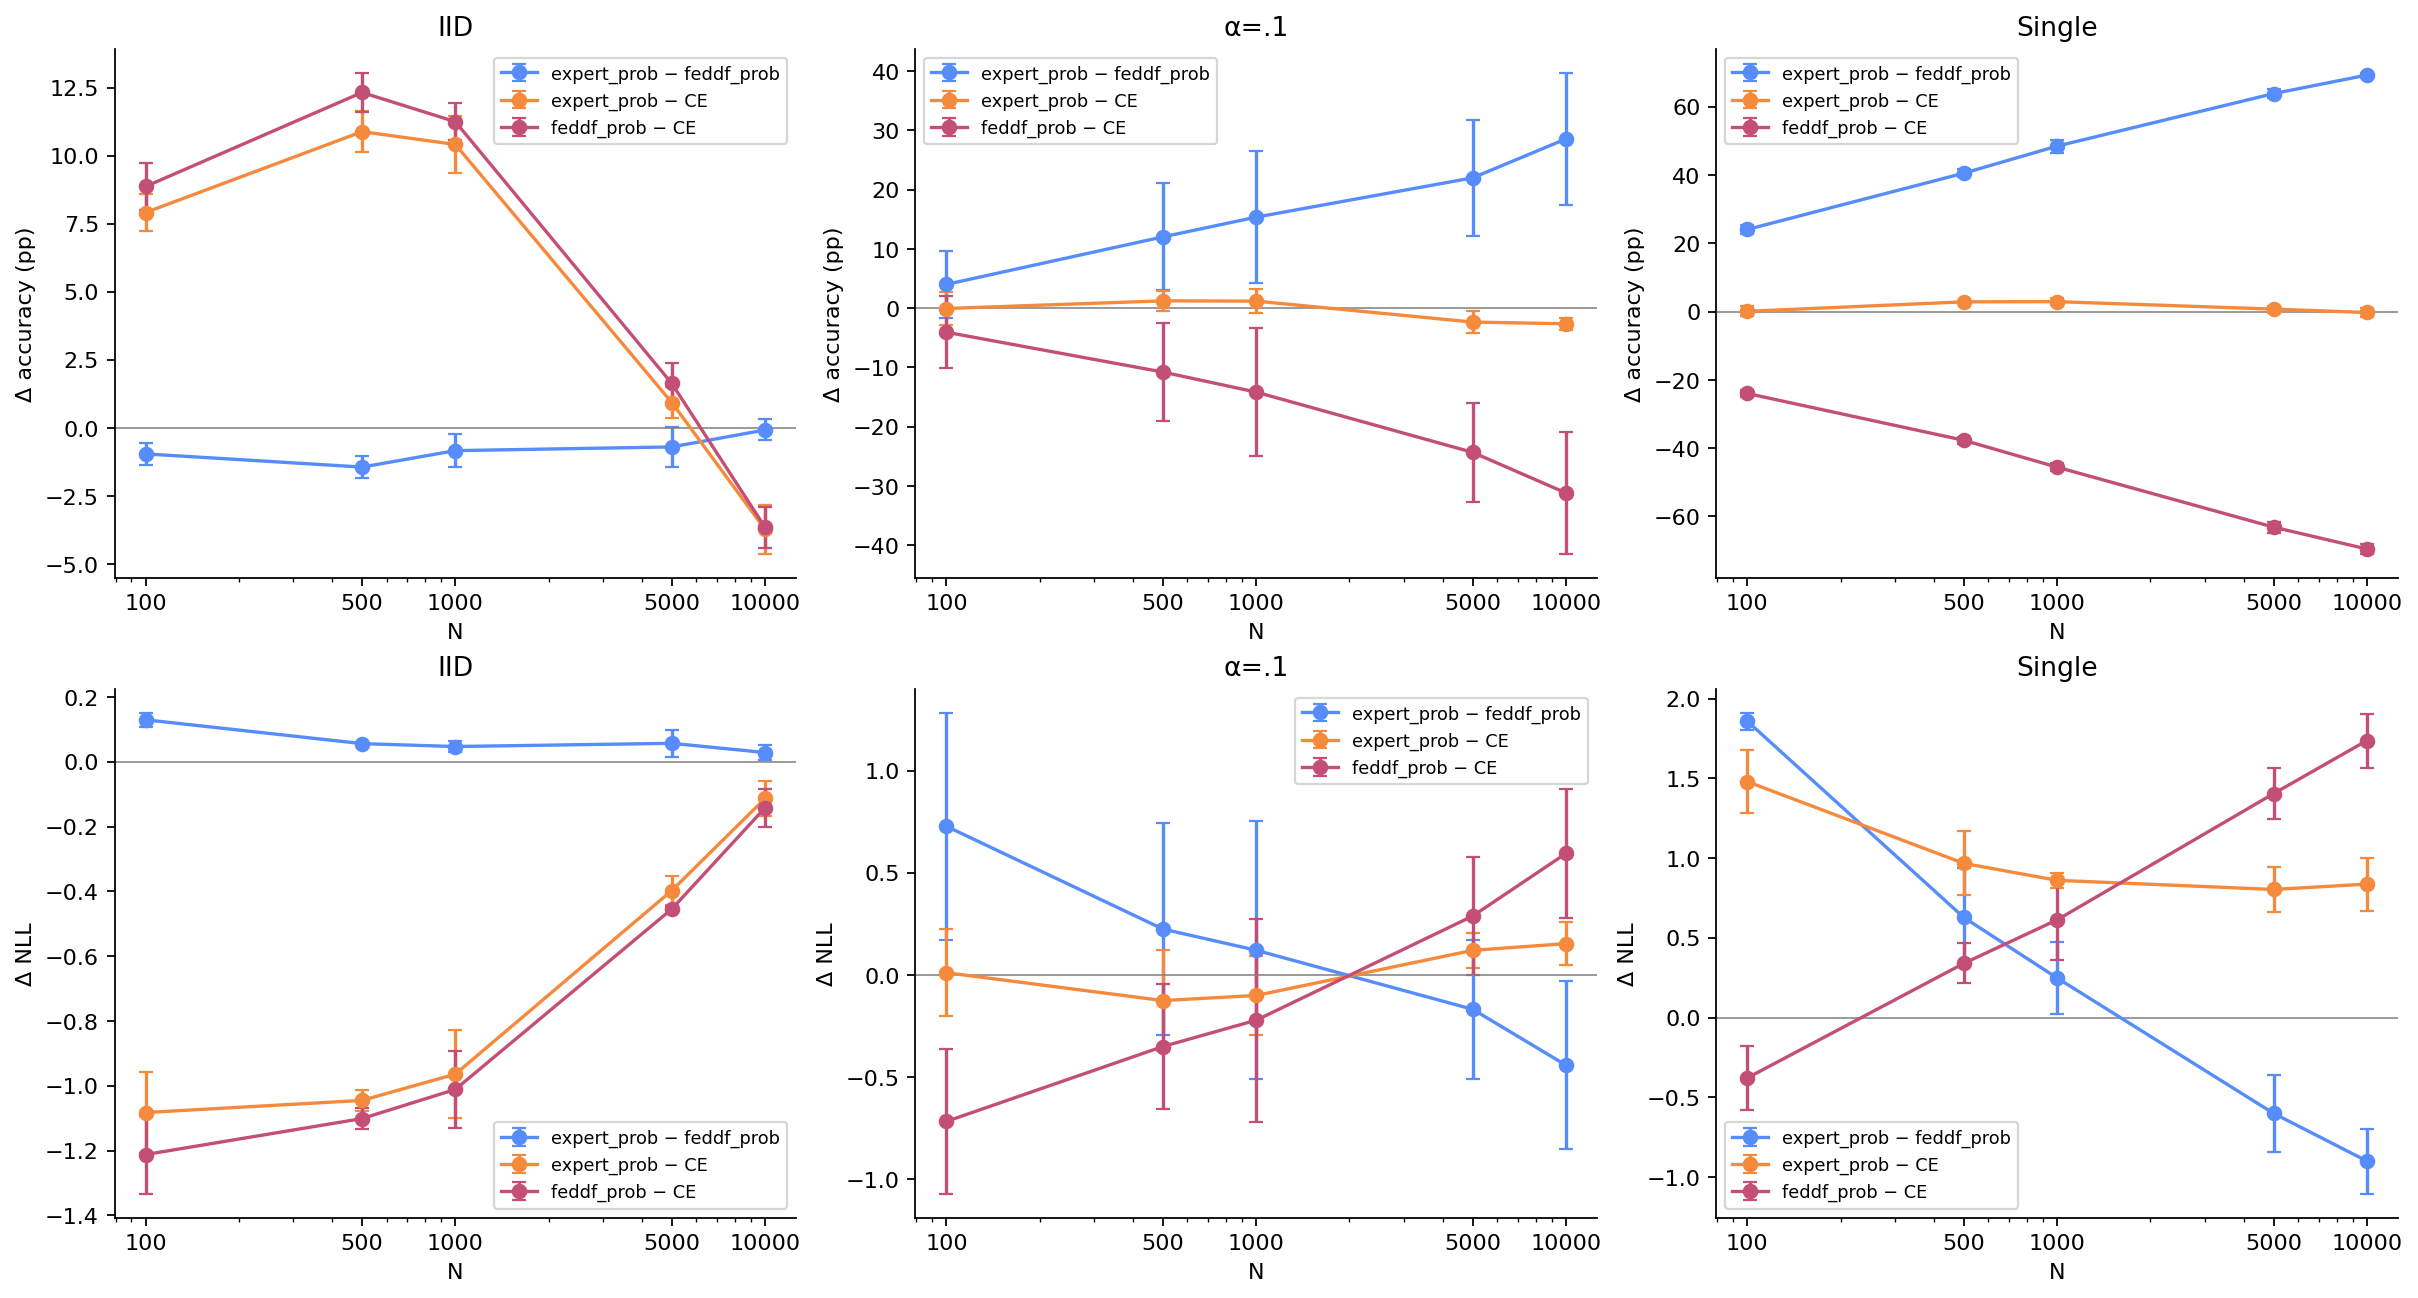

*EXPERT − CE, FedDF − CE y EXPERT − FedDF. Media ± SD calculadas después de restar dentro de cada seed. Un cruce entre N evaluados no identifica N óptimo ni umbral universal. Solo CIFAR-10.*

,seed,proxy_size,batch_size,updates,examples_seen,run_id
330,42,10000,256,1200,300000,86df58e23b62e62d03cb117d777ae2877b2827b4e3f654...
331,43,10000,256,1200,300000,ac4135f3c066f8e1019694dd1f0fec40ed9a2e2af237b6...
332,44,10000,256,1200,300000,40406ef0ff2512ec401c531613c69f7a80085603c57c26...
333,42,100,100,1200,120000,3190d167404745bc509343a87d34eebe5d3b6ac0d91cf9...
337,42,500,256,1200,300000,8588a035240f3e55cc608d8502f0a5dd28526507f2be33...
341,42,1000,256,1200,300000,25c35af941cbfc761e2daf27bb6e78580600ef827a220c...
345,42,5000,256,1200,300000,d7c5b54faf0ee7155969a97c2e17988830842bfd5ed7cc...
349,43,100,100,1200,120000,f0d05d7d758b709ca01be4ebab7177c8e819a1f7561e33...
353,43,500,256,1200,300000,450e462119cb17304e21faa68f811d1e5c52cf02f38f31...
357,43,1000,256,1200,300000,b53329337dec2e2d74ae59e1cfc8526cdac0d3c9c5e10f...


,dataset,regime,proxy_size,contrast,metric,mean,sd,n,seeds
0,cifar,alpha0p1,100,expert_prob − supervised_proxy_ce,delta_student_test_accuracy,-0.066667,2.715075,3,"42,43,44"
1,cifar,alpha0p1,100,expert_prob − supervised_proxy_ce,delta_student_test_nll,0.011115,0.212525,3,"42,43,44"
2,cifar,alpha0p1,500,expert_prob − supervised_proxy_ce,delta_student_test_accuracy,1.226667,1.651948,3,"42,43,44"
3,cifar,alpha0p1,500,expert_prob − supervised_proxy_ce,delta_student_test_nll,-0.125180,0.247702,3,"42,43,44"
4,cifar,alpha0p1,1000,expert_prob − supervised_proxy_ce,delta_student_test_accuracy,1.180000,2.017845,3,"42,43,44"
...,...,...,...,...,...,...,...,...,...
85,cifar,single,1000,expert_prob − feddf_prob,delta_student_test_nll,0.248097,0.225767,3,"42,43,44"
86,cifar,single,5000,expert_prob − feddf_prob,delta_student_test_accuracy,63.870000,1.306101,3,"42,43,44"
87,cifar,single,5000,expert_prob − feddf_prob,delta_student_test_nll,-0.601309,0.240684,3,"42,43,44"
88,cifar,single,10000,expert_prob − feddf_prob,delta_student_test_accuracy,69.286667,0.705006,3,"42,43,44"


In [8]:
show("ce_only")
show("proxy_absolute")
show("proxy_differences")
display(analysis["ce"][["seed","proxy_size","batch_size","updates","examples_seen","run_id"]])
display(pd.read_csv(OUT / "tables/curve_summary.csv"))

## F. Diagnóstico de máscaras

Las tablas suplementarias contienen las 5400 celdas cliente–clase con recuentos train/expertise, A, M y diferencias, además de expertos por clase, cobertura, fallback y soporte de celdas acreditadas. Se distingue clase ausente en train, falta de observaciones en expertise y umbral no superado. Expertise es el conjunto que construye M: no es evaluación independiente de esa máscara.

Regla de ejemplos: para cada dataset/régimen focal se elige la seed mediana según el número de celdas A≠M, desempate por seed. Se fija la regla sin usar efectos del student. El suplemento exporta los 54 diagnósticos, no solo estos ejemplos. La relación entre discrepancias y ventajas se presenta descriptivamente, sin convertir clientes o muestras en réplicas.

,dataset,regime,seed
0,mnist,iid,44
1,mnist,alpha0p1,43
2,mnist,single,43
3,fmnist,iid,44
4,fmnist,alpha0p1,43
5,fmnist,single,43
6,cifar,iid,44
7,cifar,alpha0p1,42
8,cifar,single,43


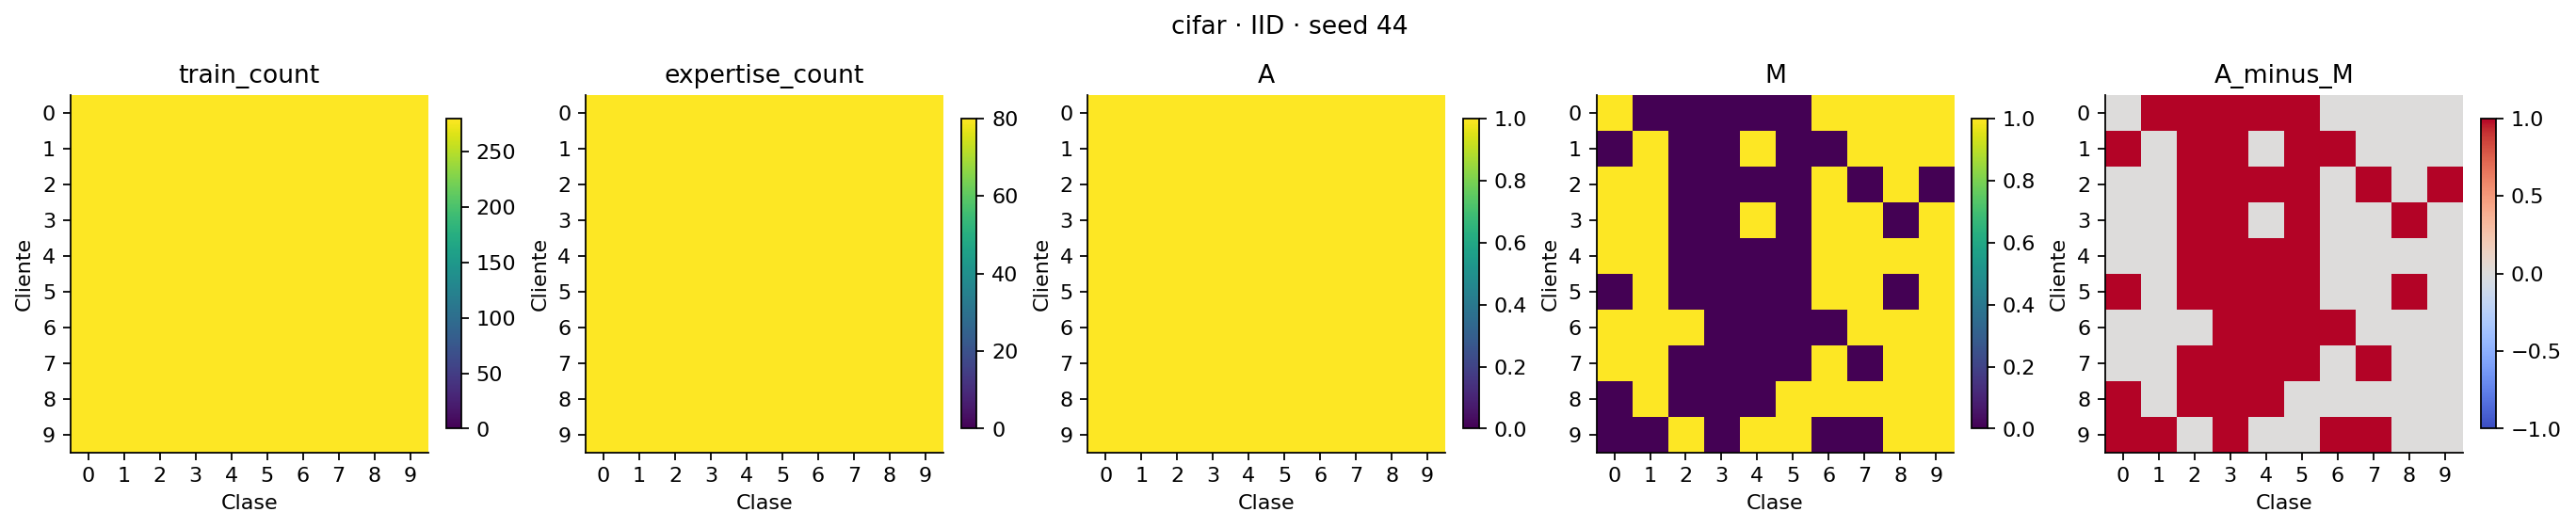

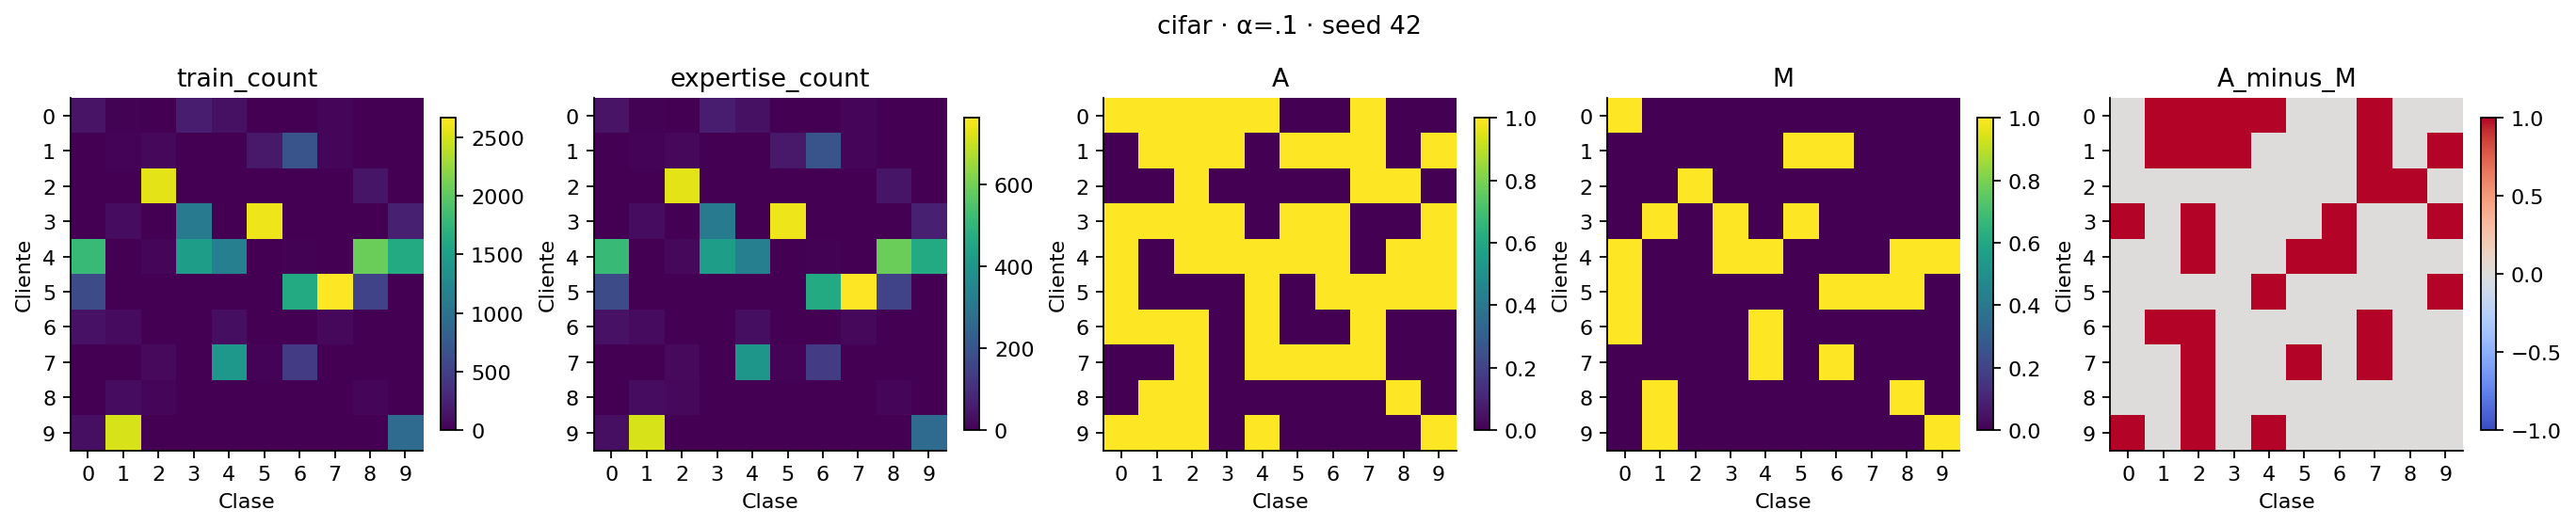

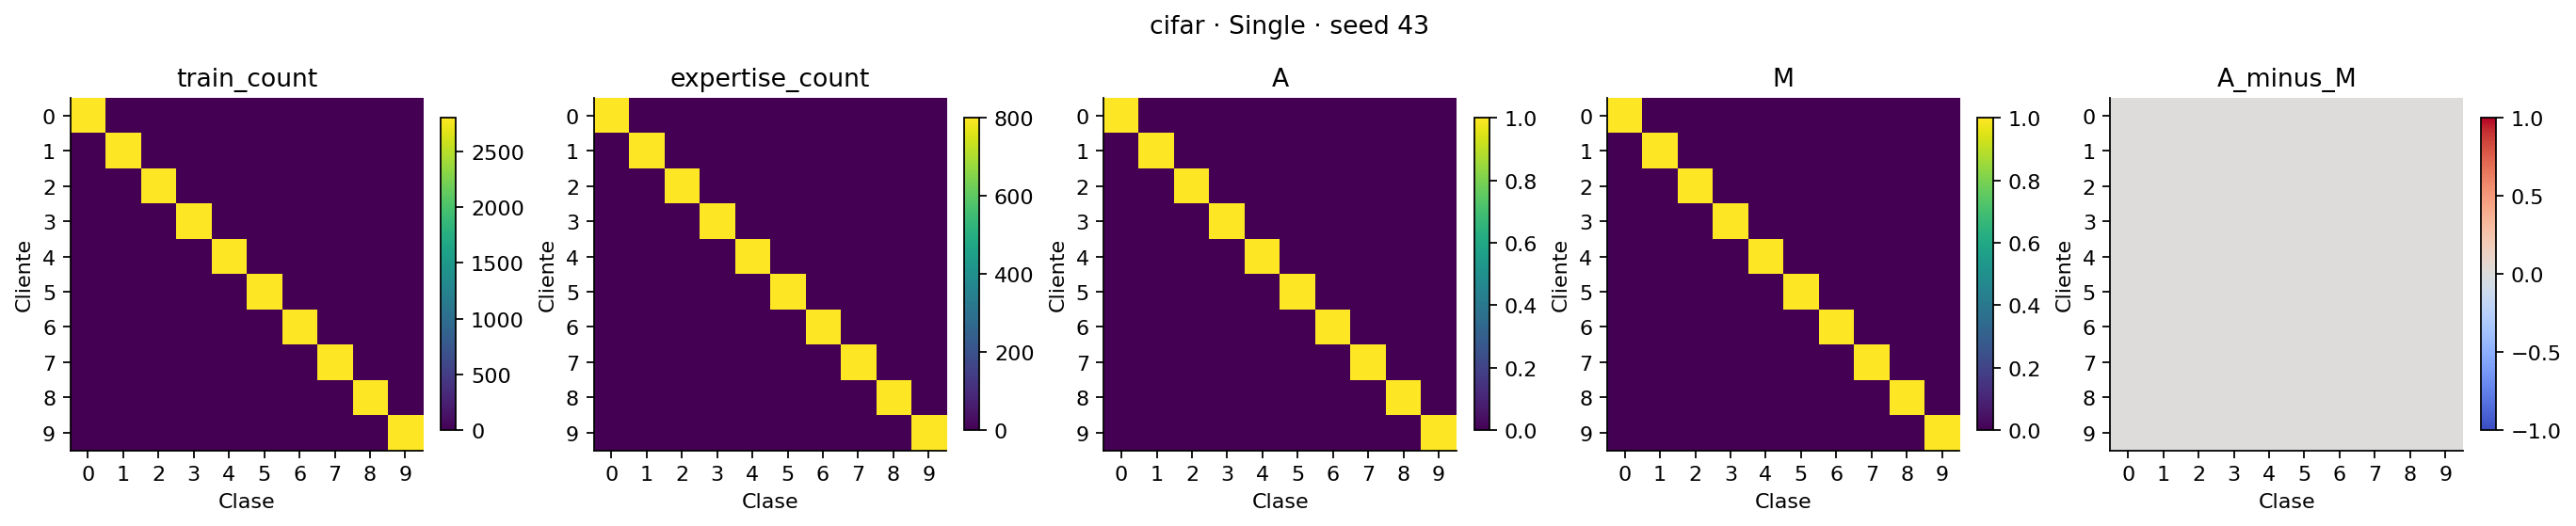

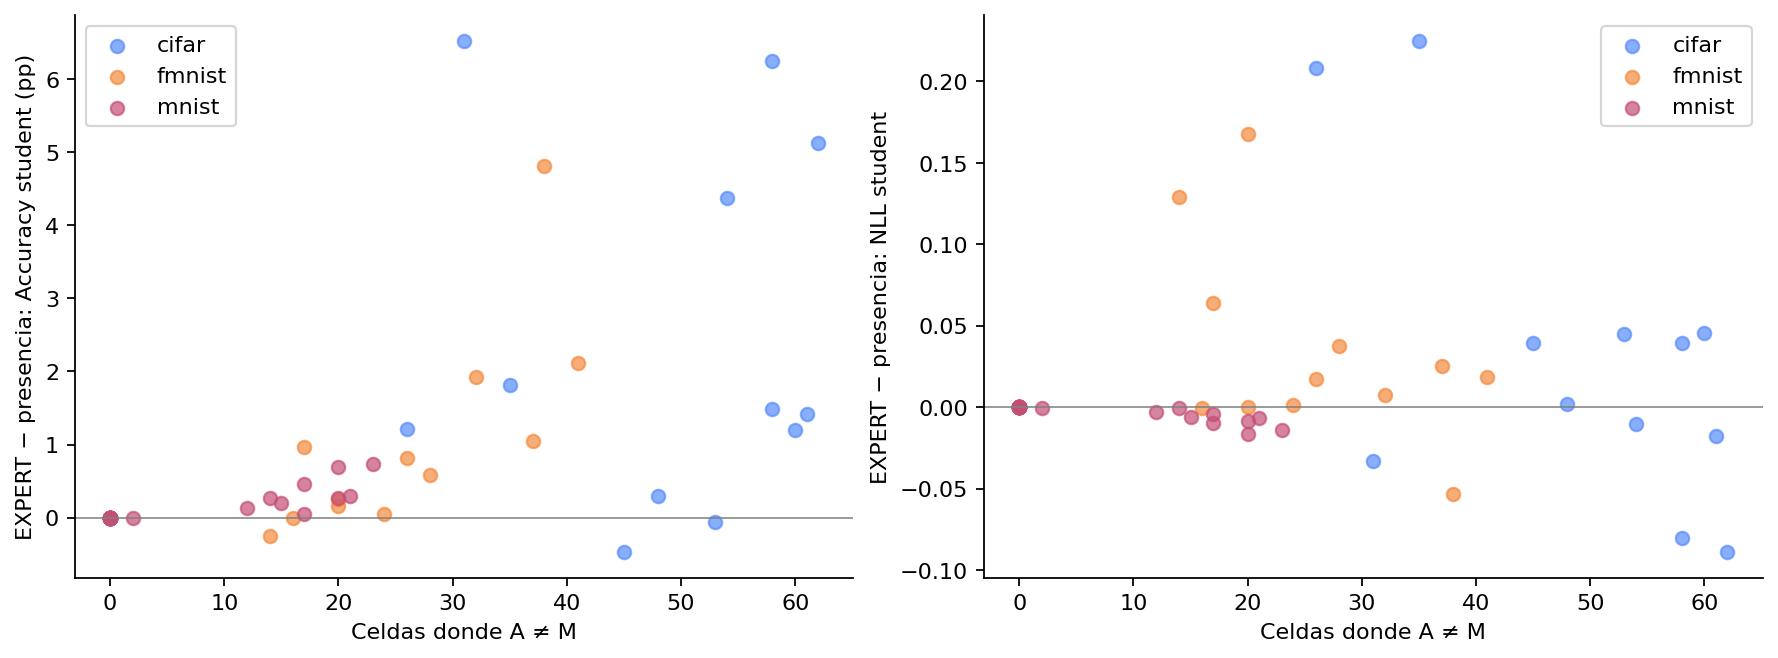

*Relación descriptiva de discrepancias A/M con ventaja de EXPERT. Puede cambiar el número de participantes; no aísla calidad respecto a cantidad. Clientes y muestras no son réplicas estadísticas.*

,dataset,regime,seed,presence_density,expertise_density,mask_disagreements,absent_train,no_expertise,min,median,max
0,cifar,alpha0p1,42,0.55,0.24,31,45,49,13,289.0,761
1,cifar,alpha0p1,43,0.59,0.24,35,41,47,8,282.0,743
2,cifar,alpha0p1,44,0.56,0.30,26,44,47,18,264.0,523
3,cifar,alpha0p5,42,0.98,0.40,58,2,6,29,129.5,459
4,cifar,alpha0p5,43,0.98,0.36,62,2,7,29,118.0,452
5,cifar,alpha0p5,44,0.94,0.40,54,6,8,44,123.0,451
6,cifar,alpha1p0,42,0.99,0.41,58,1,1,25,112.0,348
7,cifar,alpha1p0,43,1.00,0.39,61,0,1,40,109.0,288
8,cifar,alpha1p0,44,1.00,0.40,60,0,2,22,137.0,323
9,cifar,iid,42,1.00,0.55,45,0,0,80,80.0,80


,dataset,regime,seed,class,presence_teachers,expert_teachers
0,cifar,alpha0p1,42,0,6,4
1,cifar,alpha0p1,42,1,6,3
2,cifar,alpha0p1,42,2,9,1
3,cifar,alpha0p1,42,3,4,2
4,cifar,alpha0p1,42,4,6,3
...,...,...,...,...,...,...
535,mnist,single,44,5,1,1
536,mnist,single,44,6,1,1
537,mnist,single,44,7,1,1
538,mnist,single,44,8,1,1


In [9]:
representatives = pd.read_csv(OUT / "tables/representative_masks.csv")
display(representatives)
for row in representatives[representatives.dataset.eq("cifar")].itertuples():
    show(f"masks_{row.dataset}_{row.regime}_{row.seed}")
show("mask_advantage")
display(pd.read_csv(OUT / "tables/mask_statistics.csv"))
display(pd.read_csv(OUT / "tables/experts_per_class.csv"))

## 3. Interpretación y límites derivados de los resultados

Las tablas siguientes enumeran por contraste y dataset los regímenes con signo positivo/negativo, rango de medias y número de condiciones con tres seeds. Sirven para redactar resultados sin imponer una narrativa histórica. Los resultados de SR se contrastan por separado en target y student; cualquier excepción se conserva.

Los controles opcionales están disponibles de forma parcial y no invalidan el cierre del diseño principal. No hay justificación para presentar ausencia de significación como equivalencia, ni para transformar asociaciones de máscaras en causalidad sobre calidad. Los controles internos no constituyen una comparación exhaustiva con SOTA. No se han ejecutado aquí controles de concentración, unlabeled proxy, inversión de modelos ni personalización.

In [10]:
from article1.editorial import interpretation
display(Markdown(interpretation(OUT, analysis)))
display(findings)
print("Cierre auditado:", analysis["manifest"]["closed"])
print("Students principales/acordados:", analysis["manifest"]["unique_main_students"])
print("Opcionales válidos:", int(runs[runs.method.isin(["expert_logit","confidence_logit","consensus_logit","energy_logit"])].valid.sum()))
display(pd.read_csv(OUT / "tables/pending_conditions.csv"))

## Lectura de los contrastes observados

Los números siguientes son medias ± SD de diferencias dentro de seed; no son intervalos de confianza.

### EXPERT-prob − Presence-prob

**mnist**. IID: +0.00 ± 0.00 pp (n=3); α=1: +0.13 ± 0.08 pp (n=3); α=.5: +0.43 ± 0.26 pp (n=3); α=.1: +0.47 ± 0.21 pp (n=3); Multi: +0.00 ± 0.00 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**fmnist**. IID: +0.07 ± 0.09 pp (n=3); α=1: +0.82 ± 0.24 pp (n=3); α=.5: +2.95 ± 1.61 pp (n=3); α=.1: +0.32 ± 0.61 pp (n=3); Multi: +0.00 ± 0.00 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**cifar**. IID: -0.08 ± 0.39 pp (n=3); α=1: +1.37 ± 0.15 pp (n=3); α=.5: +5.25 ± 0.94 pp (n=3); α=.1: +3.18 ± 2.91 pp (n=3); Multi: +0.00 ± 0.00 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

### ORACLE-logit − FedDF-logit

**mnist**. IID: +0.12 ± 0.05 pp (n=3); α=1: +0.45 ± 0.11 pp (n=3); α=.5: +2.21 ± 1.17 pp (n=3); α=.1: +29.24 ± 17.97 pp (n=3); Multi: +58.85 ± 3.29 pp (n=3); Single: +88.49 ± 0.04 pp (n=3).

**fmnist**. IID: +0.57 ± 0.24 pp (n=3); α=1: +2.67 ± 1.45 pp (n=3); α=.5: +4.30 ± 1.34 pp (n=3); α=.1: +34.63 ± 14.11 pp (n=3); Multi: +69.22 ± 0.71 pp (n=3); Single: +79.95 ± 1.28 pp (n=3).

**cifar**. IID: +1.35 ± 0.79 pp (n=3); α=1: +3.64 ± 0.53 pp (n=3); α=.5: +9.86 ± 3.10 pp (n=3); α=.1: +38.93 ± 11.14 pp (n=3); Multi: +38.33 ± 7.33 pp (n=3); Single: +68.89 ± 0.91 pp (n=3).

### EXPERT-prob − FedDF-prob

**mnist**. IID: +0.00 ± 0.00 pp (n=3); α=1: +0.12 ± 0.08 pp (n=3); α=.5: +0.88 ± 0.75 pp (n=3); α=.1: +15.34 ± 10.44 pp (n=3); Multi: +43.48 ± 2.29 pp (n=3); Single: +88.73 ± 0.06 pp (n=3).

**fmnist**. IID: +0.07 ± 0.09 pp (n=3); α=1: +0.98 ± 0.14 pp (n=3); α=.5: +3.15 ± 1.22 pp (n=3); α=.1: +24.81 ± 15.03 pp (n=3); Multi: +50.97 ± 3.66 pp (n=3); Single: +80.30 ± 0.35 pp (n=3).

**cifar**. IID: -0.08 ± 0.39 pp (n=3); α=1: +1.38 ± 0.16 pp (n=3); α=.5: +6.54 ± 0.93 pp (n=3); α=.1: +28.56 ± 11.18 pp (n=3); Multi: +26.87 ± 4.15 pp (n=3); Single: +69.29 ± 0.71 pp (n=3).

### ORACLE-prob − EXPERT-prob

**mnist**. IID: +0.12 ± 0.08 pp (n=3); α=1: +0.23 ± 0.08 pp (n=3); α=.5: +0.34 ± 0.20 pp (n=3); α=.1: +0.22 ± 0.04 pp (n=3); Multi: +0.02 ± 0.03 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**fmnist**. IID: +0.60 ± 0.17 pp (n=3); α=1: +0.88 ± 0.13 pp (n=3); α=.5: +0.62 ± 0.86 pp (n=3); α=.1: +0.36 ± 0.38 pp (n=3); Multi: -0.06 ± 0.32 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**cifar**. IID: +1.09 ± 0.33 pp (n=3); α=1: +1.05 ± 0.68 pp (n=3); α=.5: +0.51 ± 1.41 pp (n=3); α=.1: -4.06 ± 1.30 pp (n=3); Multi: +0.02 ± 0.66 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

### FedDF-prob − FedDF-logit

**mnist**. IID: +0.05 ± 0.05 pp (n=3); α=1: +0.09 ± 0.07 pp (n=3); α=.5: +1.00 ± 0.63 pp (n=3); α=.1: +13.69 ± 8.00 pp (n=3); Multi: +15.37 ± 5.34 pp (n=3); Single: -0.24 ± 0.09 pp (n=3).

**fmnist**. IID: -0.03 ± 0.05 pp (n=3); α=1: +0.89 ± 1.33 pp (n=3); α=.5: +0.82 ± 0.44 pp (n=3); α=.1: +9.60 ± 1.04 pp (n=3); Multi: +18.55 ± 3.18 pp (n=3); Single: -0.35 ± 0.93 pp (n=3).

**cifar**. IID: +0.15 ± 0.33 pp (n=3); α=1: +1.36 ± 0.58 pp (n=3); α=.5: +3.54 ± 2.08 pp (n=3); α=.1: +12.54 ± 1.51 pp (n=3); Multi: +11.39 ± 3.44 pp (n=3); Single: -0.40 ± 0.76 pp (n=3).

### ORACLE-prob − ORACLE-logit

**mnist**. IID: +0.05 ± 0.03 pp (n=3); α=1: -0.01 ± 0.04 pp (n=3); α=.5: +0.01 ± 0.05 pp (n=3); α=.1: +0.01 ± 0.09 pp (n=3); Multi: +0.01 ± 0.07 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**fmnist**. IID: +0.07 ± 0.18 pp (n=3); α=1: +0.07 ± 0.15 pp (n=3); α=.5: +0.29 ± 0.24 pp (n=3); α=.1: +0.15 ± 0.49 pp (n=3); Multi: +0.24 ± 0.48 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**cifar**. IID: -0.19 ± 0.80 pp (n=3); α=1: +0.14 ± 0.16 pp (n=3); α=.5: +0.74 ± 0.47 pp (n=3); α=.1: -1.89 ± 2.29 pp (n=3); Multi: -0.05 ± 0.83 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

### EXPERT-prob − EXPERT-logit

**mnist**. IID: +0.01 ± 0.01 pp (n=3); α=1: +0.03 ± 0.04 pp (n=3); α=.5: +0.09 ± 0.03 pp (n=3); α=.1: -0.03 ± 0.07 pp (n=3); Multi: +0.01 ± 0.02 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**fmnist**. IID: +0.02 ± 0.08 pp (n=3); α=1: +0.02 ± 0.19 pp (n=3); α=.5: +0.24 ± 0.20 pp (n=3); α=.1: -0.16 ± 0.40 pp (n=3); Multi: +0.17 ± 0.41 pp (n=3); Single: +0.00 ± 0.00 pp (n=3).

**cifar**. IID: +0.18 ± no estimable pp (n=1); α=1: +0.80 ± no estimable pp (n=1); α=.5: +1.16 ± no estimable pp (n=1); α=.1: +2.80 ± no estimable pp (n=1); Multi: -0.11 ± no estimable pp (n=1); Single: sin pares.

### Presencia: alcance de la acreditación

En Multi y Single las máscaras A y M coinciden en las condiciones verificadas y los resultados de ambos brazos coinciden. Este resultado describe esas máscaras concretas; no constituye una prueba estadística general de equivalencia.

La ventaja de accuracy en Dirichlet debe leerse junto al NLL y al cambio en el número de participantes. En CIFAR-10 y Fashion-MNIST el NLL de EXPERT frente a presencia empeora en α=1 y α=.1, pese a la ventaja media de accuracy. Por tanto, acreditar competencia no proporciona una mejora uniforme de ambas métricas.

### SR − EXPERT: excepciones y mecanismo abierto

**mnist**. NLL target: sube en ninguno; baja en IID, α=1, α=.5, α=.1, Multi, Single. Accuracy student: sube en α=1, α=.5, Single; baja en α=.1, Multi. NLL student: sube en α=.5, α=.1, Multi; baja en IID, α=1, Single.

**fmnist**. NLL target: sube en ninguno; baja en IID, α=1, α=.5, α=.1, Multi, Single. Accuracy student: sube en Single; baja en IID, α=1, α=.5, α=.1, Multi. NLL student: sube en IID, α=1, α=.5, α=.1, Multi; baja en Single.

**cifar**. NLL target: sube en ninguno; baja en IID, α=1, α=.5, α=.1, Multi, Single. Accuracy student: sube en Single; baja en IID, α=1, α=.5, α=.1, Multi. NLL student: sube en IID, α=1, α=.5, α=.1, Multi, Single; baja en ninguno.

El target tiene una garantía algebraica sobre la etiqueta proxy que no se transfiere al riesgo del student. Las excepciones en MNIST y Fashion-MNIST impiden afirmar daño universal por SR; falta un control de concentración para distinguir mecanismos.

### Curva CIFAR-10

**IID, expert_prob − feddf_prob**: N=100: -0.96 ± 0.41 pp; N=10000: -0.08 ± 0.39 pp. Cambios de signo de la media entre puntos: ninguno.

**IID, expert_prob − CE**: N=100: +7.91 ± 0.68 pp; N=10000: -3.73 ± 0.89 pp. Cambios de signo de la media entre puntos: 5000–10000.

**IID, feddf_prob − CE**: N=100: +8.87 ± 0.85 pp; N=10000: -3.65 ± 0.74 pp. Cambios de signo de la media entre puntos: 5000–10000.

**α=.1, expert_prob − feddf_prob**: N=100: +4.01 ± 5.63 pp; N=10000: +28.56 ± 11.18 pp. Cambios de signo de la media entre puntos: ninguno.

**α=.1, expert_prob − CE**: N=100: -0.07 ± 2.72 pp; N=10000: -2.64 ± 1.05 pp. Cambios de signo de la media entre puntos: 100–500, 1000–5000.

**α=.1, feddf_prob − CE**: N=100: -4.07 ± 6.06 pp; N=10000: -31.20 ± 10.22 pp. Cambios de signo de la media entre puntos: ninguno.

**Single, expert_prob − feddf_prob**: N=100: +24.07 ± 1.38 pp; N=10000: +69.29 ± 0.71 pp. Cambios de signo de la media entre puntos: ninguno.

**Single, expert_prob − CE**: N=100: +0.09 ± 1.48 pp; N=10000: -0.25 ± 1.29 pp. Cambios de signo de la media entre puntos: 5000–10000.

**Single, feddf_prob − CE**: N=100: -23.98 ± 0.95 pp; N=10000: -69.54 ± 1.32 pp. Cambios de signo de la media entre puntos: ninguno.

Los cambios de signo son interpolaciones descriptivas entre puntos evaluados, no umbrales identificados. En IID, EXPERT−FedDF tiene accuracy media negativa en los cinco tamaños; en α=.1 y Single es positiva. La ventaja frente a CE depende de N y no se deduce de la ventaja frente a FedDF.


,contrast,dataset,positive_accuracy_regimes,negative_accuracy_regimes,negative_nll_regimes,accuracy_min_pp,accuracy_max_pp,complete_regimes
0,competence_presence,cifar,"alpha0p1,alpha0p5,alpha1p0",iid,alpha0p5,-0.076667,5.246667,6
1,competence_presence,fmnist,"alpha0p1,alpha0p5,alpha1p0,iid",,alpha0p5,0.000000,2.950000,6
2,competence_presence,mnist,"alpha0p1,alpha0p5,alpha1p0",,"alpha0p1,alpha0p5,alpha1p0,iid",0.000000,0.473333,6
3,expert_ce,cifar,,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single","alpha0p5,alpha1p0,iid",-3.916667,-0.253333,6
4,expert_ce,fmnist,"multi,single","alpha0p1,alpha0p5,alpha1p0,iid","alpha0p5,alpha1p0,iid",-1.026667,0.523333,6
5,expert_ce,mnist,"alpha0p1,multi,single","alpha0p5,alpha1p0,iid",,-0.563333,0.176667,6
6,expertise,cifar,"alpha0p1,alpha0p5,alpha1p0,multi,single",iid,"alpha0p1,alpha0p5,single",-0.076667,69.286667,6
7,expertise,fmnist,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single",,"alpha0p1,alpha0p5,multi",0.066667,80.296667,6
8,expertise,mnist,"alpha0p1,alpha0p5,alpha1p0,multi,single",,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single",0.000000,88.730000,6
9,feddf_ce,cifar,,"alpha0p1,alpha0p5,alpha1p0,iid,multi,single","alpha1p0,iid",-69.540000,-3.653333,6


Cierre auditado: True
Students principales/acordados: 471
Opcionales válidos: 164


,block,dataset,regime,seed,method,proxy_size,found,valid,paired,status,reason


## 4. Estructura argumental del artículo y mapa afirmación–evidencia

Conjunto principal propuesto: panorama global en dos paneles; selección/competencia; pooling; target–student; CE sola y diferencias por N. Routing detallado, masa externa, curvas absolutas redundantes y los 54 diagnósticos de máscaras pueden ir al suplemento. Los captions exportados especifican signo, incertidumbre y alcance.

La estructura y el mapa siguientes se generan junto a las evidencias de esta ejecución. Related Work requiere una revisión bibliográfica al redactar: este cuaderno no fabrica una comparación externa ni citas ausentes.

In [11]:
display(structure)
display(claims)
# Integridad final: cada entrada auditada sigue coincidiendo con su huella al terminar.
from article1.hashes import file_sha256
changed = [item["original"] for item in analysis["manifest"]["inputs"]
           if file_sha256(Path(item["original"])) != item["sha256"]]
assert not changed, f"Entradas cambiaron durante el análisis: {changed}"
analysis["manifest"]["inputs_unchanged_after_analysis"] = True
(OUT / "manifest.json").write_text(json.dumps(analysis["manifest"], indent=2) + "\n")
print("Entradas originales sin cambios; manifiesto:", OUT / "manifest.json")

,section,question_message,evidence,figure_table,cannot_claim
0,1. Introducción,¿Aporta medir competencia de clase al transfer...,"selection, expertise, competence_presence",selection_competence; contrasts,"No superioridad universal, ni comparación exha..."
1,2. Related Work,Posicionar selección y pooling respecto a ense...,"Definiciones e implementaciones de FedDF, rout...",Método y protocolo; sin tabla SOTA nueva,Estos controles internos no sustituyen benchma...
2,3. Método,A desde train; M desde expertise; pooling unif...,"mask_cells, target_checks y código de distilla...",masks_*; routing,ORACLE usa etiquetas proxy y no es cota garant...
3,4. Protocolo experimental,"Tres seeds, splits disjuntos, 10 teachers, 120...",manifest; teacher_states; proxy_subsets; runs;...,coverage; input_inventory,Hashes registrados del student no reevalúan te...
4,5. Resultados,Selección → competencia/presencia → pooling → ...,Contrastes emparejados individuales; conclusio...,overview_references; overview_ablations; selec...,No equivalencia por diferencias pequeñas; SR c...
5,6. Discusión y limitaciones,Separar observaciones de mecanismos y alcance.,Excepciones en findings; opcionales y condicio...,findings; optional_coverage; pending_condition...,n=3 limita inferencia; no generalizar entre da...
6,7. Conclusiones y futuro,Concluir únicamente los contrastes respaldados...,Mapa hipótesis–evidencia y estado de cierre,claim_evidence,"Entropía/concentración, unlabeled proxy, inver..."


,hypothesis,contrast,result,defensible_claim,limitation,status
0,selection,oracle_logit − feddf_logit,"[{""contrast"": ""selection"", ""dataset"": ""cifar"",...",Efecto observado del procedimiento por dataset...,"Tres seeds; no equivalencia, causalidad de mec...",54/54 pares; completo
1,expertise,expert_prob − feddf_prob,"[{""contrast"": ""expertise"", ""dataset"": ""cifar"",...",Efecto observado del procedimiento por dataset...,"Tres seeds; no equivalencia, causalidad de mec...",54/54 pares; completo
2,oracle_expert,oracle_prob − expert_prob,"[{""contrast"": ""oracle_expert"", ""dataset"": ""cif...",Efecto observado del procedimiento por dataset...,"Tres seeds; no equivalencia, causalidad de mec...",54/54 pares; completo
3,competence_presence,expert_prob − presence_prob,"[{""contrast"": ""competence_presence"", ""dataset""...",Efecto observado del procedimiento por dataset...,Calidad y número de teachers pueden cambiar.,54/54 pares; completo
4,pooling_feddf,feddf_prob − feddf_logit,"[{""contrast"": ""pooling_feddf"", ""dataset"": ""cif...",Efecto observado del procedimiento por dataset...,"Tres seeds; no equivalencia, causalidad de mec...",54/54 pares; completo
5,pooling_oracle,oracle_prob − oracle_logit,"[{""contrast"": ""pooling_oracle"", ""dataset"": ""ci...",Efecto observado del procedimiento por dataset...,"Tres seeds; no equivalencia, causalidad de mec...",54/54 pares; completo
6,pooling_expert,expert_prob − expert_logit,"[{""contrast"": ""pooling_expert"", ""dataset"": ""ci...",Efecto observado del procedimiento por dataset...,"Tres seeds; no equivalencia, causalidad de mec...",41/54 pares; alcance parcial
7,support,expert_prob_sr − expert_prob,"[{""contrast"": ""support"", ""dataset"": ""cifar"", ""...",Efecto observado del procedimiento por dataset...,SR cambia concentración e información intercla...,54/54 pares; completo
8,public_labels_proxy_budget,EXPERT−CE / FedDF−CE / EXPERT−FedDF,135/135 pares en CIFAR-10,Curvas para cinco N evaluados.,CE reutilizado; 1200 updates; batch 100 para N...,descriptivo


Entradas originales sin cambios; manifiesto: /home/roi/PycharmProjects/KD_v5/OUTPUTS/article1_paper/manifest.json
